<a href="https://colab.research.google.com/github/IanCastillo0621/tsp-bio-inspired-algorithms/blob/main/gen%C3%A9tico_sp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install pandas openpyxl numpy

In [ ]:
import io, numpy as np, pandas as pd
from google.colab import files

uploaded = files.upload()
xlsx_name = list(uploaded.keys())[0]
xlsx_bytes = io.BytesIO(uploaded[xlsx_name])

xls = pd.ExcelFile(xlsx_bytes)
sheet_names = xls.sheet_names

globals_dict = globals()
dfs = []
labels_list = []

for i, sh in enumerate(sheet_names, start=1):
    df = pd.read_excel(xls, sheet_name=sh, header=0, index_col=0)
    df = df.apply(pd.to_numeric, errors='coerce').fillna(np.inf)

    var_name = f"df{i}"
    globals_dict[var_name] = df
    dfs.append(df)
    labels_list.append(df.index.tolist())

    print(f"{var_name} cargado (hoja='{sh}', shape={df.shape})")

print(f"\nTotal hojas leídas: {len(dfs)}")

Saving matrices_40.xlsx to matrices_40.xlsx
df1 cargado (hoja='Instancia_1', shape=(40, 40))
df2 cargado (hoja='Instancia_2', shape=(40, 40))
df3 cargado (hoja='Instancia_3', shape=(40, 40))
df4 cargado (hoja='Instancia_4', shape=(40, 40))
df5 cargado (hoja='Instancia_5', shape=(40, 40))
df6 cargado (hoja='Instancia_6', shape=(40, 40))
df7 cargado (hoja='Instancia_7', shape=(40, 40))
df8 cargado (hoja='Instancia_8', shape=(40, 40))
df9 cargado (hoja='Instancia_9', shape=(40, 40))
df10 cargado (hoja='Instancia_10', shape=(40, 40))

Total hojas leídas: 10


In [ ]:
import random, time
import numpy as np
import matplotlib.pyplot as plt

def to_distance_matrix_with_labels(df: pd.DataFrame):
    A = df.values.astype(float).copy()
    np.fill_diagonal(A, 0.0)
    A = np.maximum(A, 0.0)
    labels = df.index.tolist()
    return A, labels

def route_length(route, dist):
    L = 0.0
    n = len(route)
    for i in range(n-1):
        L += dist[route[i], route[i+1]]
    L += dist[route[-1], route[0]]
    return float(L)

def initial_population(pop_size, n):
    base = list(range(n))
    pop = []
    for _ in range(pop_size):
        indiv = base[:]
        random.shuffle(indiv)
        pop.append(indiv)
    return pop

def tournament_selection(pop, fitness, k=3):
    selected = random.sample(pop, k)
    selected.sort(key=lambda ind: fitness[tuple(ind)], reverse=True)
    return selected[0][:]

def order_crossover(p1, p2):
    n = len(p1)
    a, b = sorted(random.sample(range(n), 2))
    child = [None]*n
    child[a:b+1] = p1[a:b+1]
    fill = [g for g in p2 if g not in child]
    j = 0
    for i in range(n):
        if child[i] is None:
            child[i] = fill[j]
            j += 1
    return child

def mutate_inversion(route, p=0.2):
    if random.random() < p:
        n = len(route)
        i, j = sorted(random.sample(range(n), 2))
        route[i:j+1] = reversed(route[i:j+1])
    return route

def evaluate_population(pop, dist):
    costs, fitness = {}, {}
    for ind in pop:
        c = route_length(ind, dist)
        costs[tuple(ind)] = c
        fitness[tuple(ind)] = 1.0 / (1.0 + c)
    return costs, fitness

def ga_tsp(
    dist_matrix,
    pop_size=220,
    generations=1200,
    elite_size=2,
    tournament_k=3,
    mutation_prob=0.25,
    crossover_perc=1.0,
    patience=250,
    seed=None,
    verbose=True
):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    n = dist_matrix.shape[0]
    assert n >= 3

    pop = initial_population(pop_size, n)
    costs, fitness = evaluate_population(pop, dist_matrix)

    best_ind = min(costs, key=costs.get)
    best_cost = costs[best_ind]
    best_route = list(best_ind)
    history = [best_cost]
    no_improve = 0
    t0 = time.time()

    for gen in range(1, generations+1):
        pop.sort(key=lambda ind: costs[tuple(ind)])  # menor costo primero
        new_pop = [pop[i][:] for i in range(elite_size)]

        num_off = pop_size - elite_size
        num_cross = int(num_off * crossover_perc)
        num_copy = num_off - num_cross

        for _ in range(num_cross):
            p1 = tournament_selection(pop, fitness, k=tournament_k)
            p2 = tournament_selection(pop, fitness, k=tournament_k)
            child = order_crossover(p1, p2)
            child = mutate_inversion(child, p=mutation_prob)
            new_pop.append(child)

        for _ in range(num_copy):
            p = tournament_selection(pop, fitness, k=tournament_k)
            child = mutate_inversion(p[:], p=mutation_prob)
            new_pop.append(child)

        pop = new_pop
        costs, fitness = evaluate_population(pop, dist_matrix)

        cur_best = min(costs, key=costs.get)
        cur_cost = costs[cur_best]
        if cur_cost + 1e-9 < best_cost:
            best_cost = cur_cost
            best_route = list(cur_best)
            no_improve = 0
        else:
            no_improve += 1

        history.append(best_cost)
        if verbose and (gen % 100 == 0 or gen == 1):
            print(f"Gen {gen:4d} | Best = {best_cost:.4f}")

        if patience is not None and no_improve >= patience:
            if verbose:
                print(f"Paro por paciencia en gen {gen} (best = {best_cost:.4f})")
            break

    if verbose:
        print(f"Tiempo total: {time.time()-t0:.2f}s | Mejor costo = {best_cost:.4f}")

    return best_route, best_cost, history

def plot_history(history, title="Convergencia GA-TSP"):
    plt.figure()
    plt.plot(history)
    plt.xlabel("Generación")
    plt.ylabel("Mejor costo")
    plt.title(title)
    plt.grid(True)
    plt.show()

def route_to_labels(route, labels):
    return [labels[i] for i in route]



=== Hoja 1 (df1) ===
Gen    1 | Best = 135.0042
Gen  100 | Best = 132.9840
Gen  200 | Best = 132.9769
Gen  300 | Best = 132.9769
Paro por paciencia en gen 376 (best = 132.9769)
Tiempo total: 5.77s | Mejor costo = 132.9769


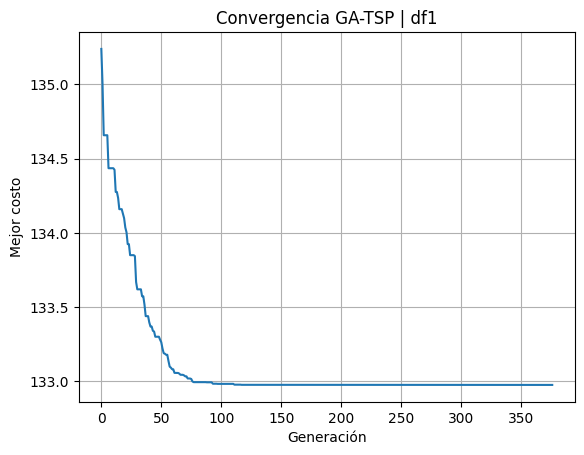

Mejor ruta (IDs): [371, 383, 225, 277, 334, 239, 213, 171, 271, 366, 226, 418, 332, 92, 48, 336, 43, 26, 20, 15, 12, 146, 147, 51, 101, 115, 63, 41, 58, 89, 112, 108, 402, 361, 388, 351, 151, 251, 163, 195]

=== Hoja 2 (df2) ===
Gen    1 | Best = 3.4835
Gen  100 | Best = 1.7343
Gen  200 | Best = 1.5069
Gen  300 | Best = 1.4685
Gen  400 | Best = 1.4429
Gen  500 | Best = 1.4378
Gen  600 | Best = 1.4301
Gen  700 | Best = 1.4301
Paro por paciencia en gen 753 (best = 1.4301)
Tiempo total: 7.78s | Mejor costo = 1.4301


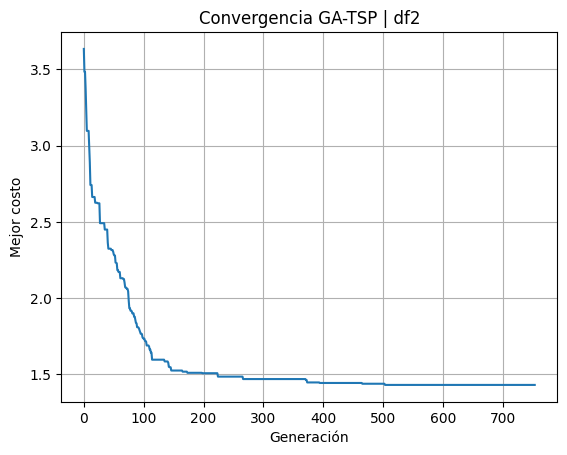

Mejor ruta (IDs): [33, 76, 56, 17, 24, 143, 122, 25, 13, 134, 30, 137, 125, 379, 130, 361, 346, 216, 401, 369, 327, 310, 155, 354, 331, 109, 72, 302, 249, 428, 403, 152, 345, 194, 392, 210, 257, 88, 161, 418]

=== Hoja 3 (df3) ===
Gen    1 | Best = 3.2337
Gen  100 | Best = 0.9548
Gen  200 | Best = 0.9371
Gen  300 | Best = 0.9371
Paro por paciencia en gen 376 (best = 0.9371)
Tiempo total: 5.05s | Mejor costo = 0.9371


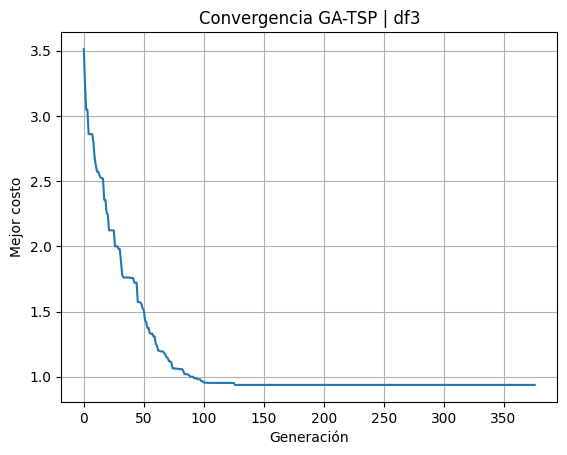

Mejor ruta (IDs): [191, 264, 391, 337, 154, 150, 151, 269, 375, 395, 117, 28, 144, 38, 16, 21, 95, 55, 132, 0, 397, 47, 350, 382, 366, 368, 376, 171, 162, 265, 266, 380, 425, 286, 365, 152, 393, 374, 157, 178]

=== Hoja 4 (df4) ===
Gen    1 | Best = 135.3115
Gen  100 | Best = 133.1974
Gen  200 | Best = 133.1090
Gen  300 | Best = 133.1090
Gen  400 | Best = 133.1090
Gen  500 | Best = 133.0877
Gen  600 | Best = 133.0877
Paro por paciencia en gen 679 (best = 133.0877)
Tiempo total: 7.09s | Mejor costo = 133.0877


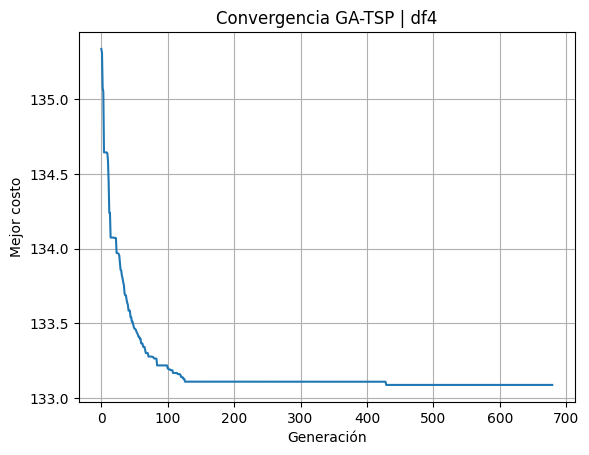

Mejor ruta (IDs): [103, 399, 16, 145, 26, 29, 90, 123, 420, 397, 74, 325, 174, 333, 314, 213, 348, 205, 209, 394, 297, 365, 425, 267, 150, 154, 175, 115, 67, 144, 52, 141, 255, 330, 173, 178, 204, 396, 398, 106]

=== Hoja 5 (df5) ===
Gen    1 | Best = 36.1090
Gen  100 | Best = 34.0715
Gen  200 | Best = 33.9320
Gen  300 | Best = 33.9286
Gen  400 | Best = 33.9286
Paro por paciencia en gen 491 (best = 33.9286)
Tiempo total: 6.28s | Mejor costo = 33.9286


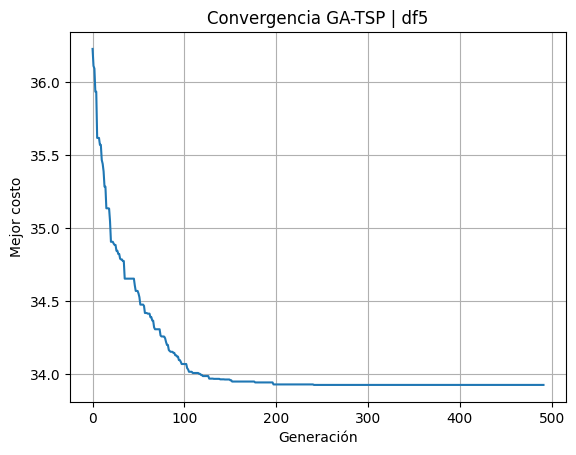

Mejor ruta (IDs): [5, 112, 28, 72, 402, 304, 355, 331, 344, 295, 312, 259, 395, 50, 63, 137, 51, 69, 39, 128, 31, 81, 79, 48, 181, 317, 284, 348, 365, 426, 372, 371, 275, 240, 256, 392, 171, 328, 210, 397]

=== Hoja 6 (df6) ===
Gen    1 | Best = 3.1511
Gen  100 | Best = 0.9926
Gen  200 | Best = 0.9926
Gen  300 | Best = 0.9729
Gen  400 | Best = 0.9729
Gen  500 | Best = 0.9729
Paro por paciencia en gen 504 (best = 0.9729)
Tiempo total: 5.28s | Mejor costo = 0.9729


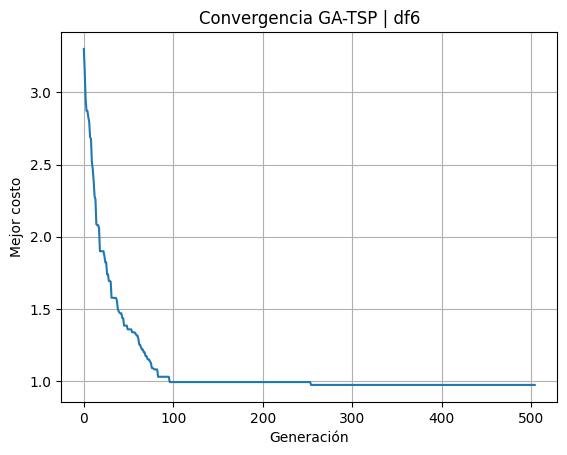

Mejor ruta (IDs): [159, 318, 182, 343, 359, 393, 219, 277, 415, 417, 223, 266, 200, 258, 302, 406, 340, 336, 282, 321, 91, 0, 105, 142, 25, 90, 29, 49, 5, 42, 130, 137, 52, 117, 304, 299, 294, 289, 259, 356]

=== Hoja 7 (df7) ===
Gen    1 | Best = 36.5778
Gen  100 | Best = 34.2518
Gen  200 | Best = 34.0324
Gen  300 | Best = 34.0136
Gen  400 | Best = 34.0136
Paro por paciencia en gen 473 (best = 34.0136)
Tiempo total: 6.83s | Mejor costo = 34.0136


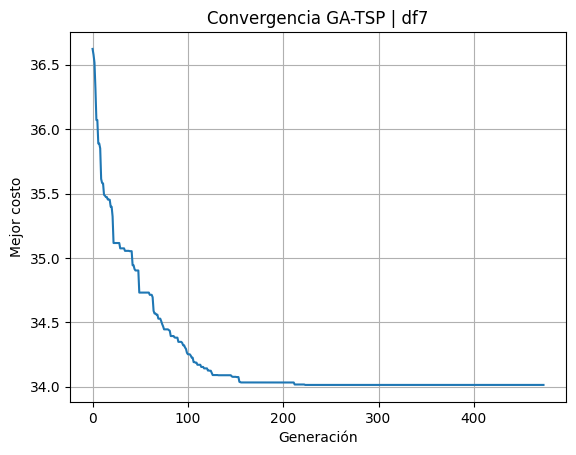

Mejor ruta (IDs): [87, 238, 109, 89, 141, 58, 120, 41, 137, 315, 198, 216, 175, 357, 204, 184, 199, 373, 396, 342, 371, 426, 234, 394, 273, 367, 208, 192, 39, 101, 3, 71, 24, 123, 210, 307, 185, 314, 272, 339]

=== Hoja 8 (df8) ===
Gen    1 | Best = 3.0760
Gen  100 | Best = 1.1650
Gen  200 | Best = 1.0916
Gen  300 | Best = 1.0916
Gen  400 | Best = 1.0916
Paro por paciencia en gen 445 (best = 1.0916)
Tiempo total: 4.63s | Mejor costo = 1.0916


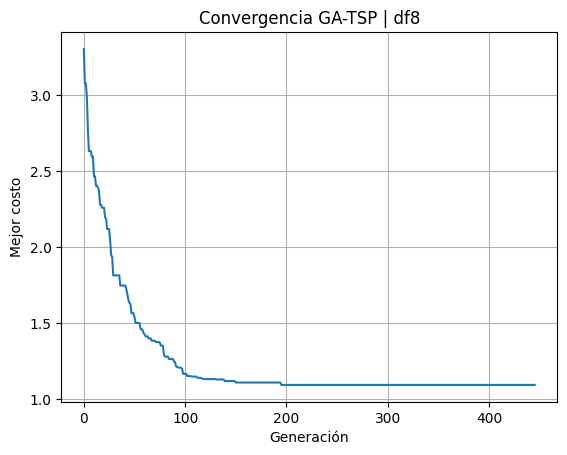

Mejor ruta (IDs): [395, 270, 255, 377, 216, 388, 291, 187, 170, 414, 330, 323, 324, 343, 349, 359, 254, 298, 275, 390, 302, 258, 213, 185, 317, 171, 37, 34, 42, 118, 124, 0, 93, 138, 95, 97, 84, 64, 46, 133]

=== Hoja 9 (df9) ===
Gen    1 | Best = 3.9355
Gen  100 | Best = 1.4977
Gen  200 | Best = 1.4366
Gen  300 | Best = 1.4258
Gen  400 | Best = 1.4258
Gen  500 | Best = 1.3392
Gen  600 | Best = 1.3354
Gen  700 | Best = 1.3354
Gen  800 | Best = 1.3316
Gen  900 | Best = 1.3316
Paro por paciencia en gen 969 (best = 1.3316)
Tiempo total: 11.19s | Mejor costo = 1.3316


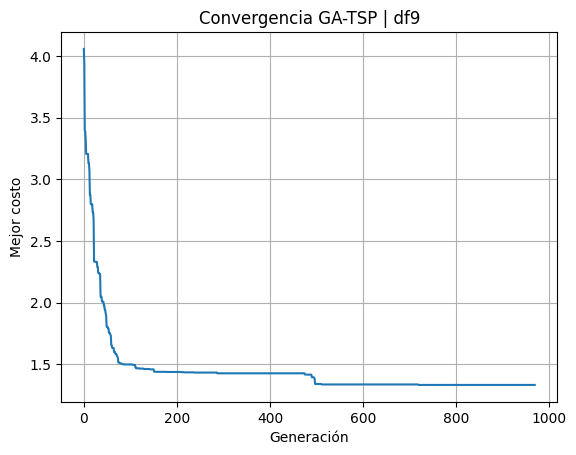

Mejor ruta (IDs): [291, 186, 346, 295, 310, 155, 299, 274, 191, 423, 302, 283, 112, 41, 46, 3, 53, 25, 105, 0, 57, 201, 76, 33, 321, 166, 278, 179, 385, 376, 427, 239, 227, 219, 253, 158, 254, 297, 428, 403]

=== Hoja 10 (df10) ===
Gen    1 | Best = 3.2361
Gen  100 | Best = 1.3806
Gen  200 | Best = 0.9821
Gen  300 | Best = 0.9821
Gen  400 | Best = 0.9821
Paro por paciencia en gen 443 (best = 0.9821)
Tiempo total: 5.82s | Mejor costo = 0.9821


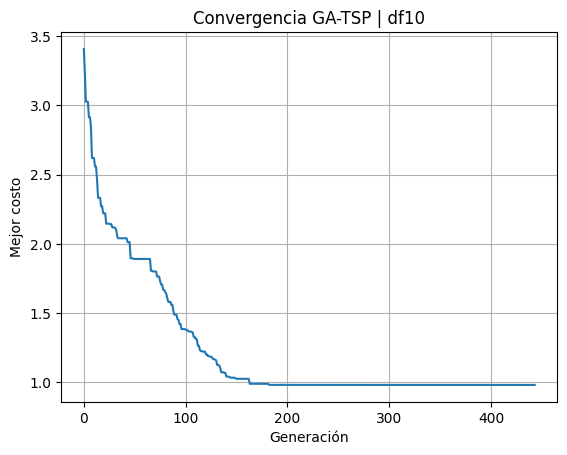

Mejor ruta (IDs): [274, 320, 266, 400, 396, 426, 225, 212, 219, 253, 227, 208, 381, 385, 316, 280, 123, 42, 11, 90, 79, 111, 35, 140, 69, 46, 144, 141, 50, 217, 409, 315, 401, 197, 150, 168, 337, 251, 295, 264]


,sheet,best_cost,n
0,df1,132.976889,40
1,df10,0.982061,40
2,df2,1.430104,40
3,df3,0.937135,40
4,df4,133.087671,40
5,df5,33.928619,40
6,df6,0.972938,40
7,df7,34.013610,40
8,df8,1.091592,40
9,df9,1.331572,40


,sheet,route_ids,length_nodes
0,df1,371->383->225->277->334->239->213->171->271->3...,40
1,df10,274->320->266->400->396->426->225->212->219->2...,40
2,df2,33->76->56->17->24->143->122->25->13->134->30-...,40
3,df3,191->264->391->337->154->150->151->269->375->3...,40
4,df4,103->399->16->145->26->29->90->123->420->397->...,40
5,df5,5->112->28->72->402->304->355->331->344->295->...,40
6,df6,159->318->182->343->359->393->219->277->415->4...,40
7,df7,87->238->109->89->141->58->120->41->137->315->...,40
8,df8,395->270->255->377->216->388->291->187->170->4...,40
9,df9,291->186->346->295->310->155->299->274->191->4...,40


Guardados: tsp_ga_results_summary.csv, tsp_ga_best_routes_ids.csv


In [ ]:
GA_PARAMS = dict(
    pop_size=220,
    generations=1200,
    elite_size=2,
    tournament_k=3,
    mutation_prob=0.25,
    crossover_perc=1.0,
    patience=250,
    seed=123,
    verbose=True
)

all_results = []
routes_rows = []

for i, df in enumerate(dfs, start=1):
    print(f"\n=== Hoja {i} (df{i}) ===")
    dist, labels = to_distance_matrix_with_labels(df)
    route, cost, hist = ga_tsp(dist, **GA_PARAMS)
    all_results.append({"sheet": f"df{i}", "best_cost": cost, "n": dist.shape[0]})
    routes_rows.append({
        "sheet": f"df{i}",
        "route_ids": "->".join(map(str, route_to_labels(route, labels))),
        "length_nodes": len(route)
    })
    plot_history(hist, title=f"Convergencia GA-TSP | df{i}")
    print("Mejor ruta (IDs):", route_to_labels(route, labels))

res_df = pd.DataFrame(all_results).sort_values("sheet").reset_index(drop=True)
routes_df = pd.DataFrame(routes_rows).sort_values("sheet").reset_index(drop=True)

display(res_df)
display(routes_df)

res_df.to_csv("tsp_ga_results_summary.csv", index=False)
routes_df.to_csv("tsp_ga_best_routes_ids.csv", index=False)
print("Guardados: tsp_ga_results_summary.csv, tsp_ga_best_routes_ids.csv")


In [ ]:
import io, numpy as np, pandas as pd
from google.colab import files

uploaded = files.upload()
xlsx_name = list(uploaded.keys())[0]
xlsx_bytes = io.BytesIO(uploaded[xlsx_name])

xls = pd.ExcelFile(xlsx_bytes)
sheet_names = xls.sheet_names

globals_dict = globals()
dfs = []
labels_list = []

for i, sh in enumerate(sheet_names, start=1):
    df = pd.read_excel(xls, sheet_name=sh, header=0, index_col=0)
    df = df.apply(pd.to_numeric, errors='coerce').fillna(np.inf)

    var_name = f"df{i}"
    globals_dict[var_name] = df
    dfs.append(df)
    labels_list.append(df.index.tolist())

    print(f"{var_name} cargado (hoja='{sh}', shape={df.shape})")

print(f"\nTotal hojas leídas: {len(dfs)}")

Saving matrices_100.xlsx to matrices_100.xlsx
df1 cargado (hoja='Instancia_1', shape=(100, 100))
df2 cargado (hoja='Instancia_2', shape=(100, 100))
df3 cargado (hoja='Instancia_3', shape=(100, 100))
df4 cargado (hoja='Instancia_4', shape=(100, 100))
df5 cargado (hoja='Instancia_5', shape=(100, 100))
df6 cargado (hoja='Instancia_6', shape=(100, 100))
df7 cargado (hoja='Instancia_7', shape=(100, 100))
df8 cargado (hoja='Instancia_8', shape=(100, 100))
df9 cargado (hoja='Instancia_9', shape=(100, 100))
df10 cargado (hoja='Instancia_10', shape=(100, 100))

Total hojas leídas: 10



=== Hoja 1 (df1) ===
Gen    1 | Best = 9.4185
Gen  100 | Best = 5.1310
Gen  200 | Best = 3.5941
Gen  300 | Best = 2.7786
Gen  400 | Best = 2.6410
Gen  500 | Best = 2.5497
Gen  600 | Best = 2.5002
Gen  700 | Best = 2.4698
Gen  800 | Best = 2.4645
Gen  900 | Best = 2.4645
Paro por paciencia en gen 963 (best = 2.4645)
Tiempo total: 40.88s | Mejor costo = 2.4645


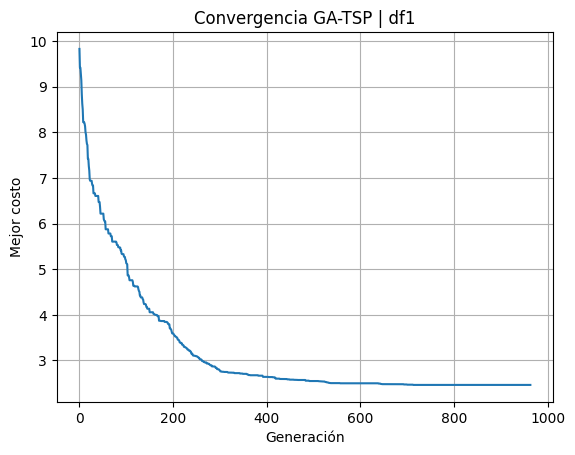

Mejor ruta (IDs): [411, 282, 181, 92, 332, 97, 146, 111, 21, 143, 56, 110, 5, 47, 328, 311, 418, 228, 174, 400, 415, 169, 348, 158, 234, 225, 157, 202, 275, 371, 267, 403, 428, 344, 178, 335, 318, 182, 396, 339, 398, 224, 249, 258, 199, 200, 268, 173, 283, 191, 109, 14, 89, 215, 164, 299, 404, 214, 170, 247, 291, 387, 312, 388, 172, 259, 216, 285, 133, 41, 38, 121, 125, 107, 116, 52, 58, 141, 28, 379, 18, 86, 43, 108, 75, 96, 13, 100, 61, 6, 35, 55, 22, 15, 139, 0, 27, 161, 177, 301]

=== Hoja 2 (df2) ===
Gen    1 | Best = 9.1258
Gen  100 | Best = 4.9819
Gen  200 | Best = 3.4861
Gen  300 | Best = 2.8478
Gen  400 | Best = 2.5911
Gen  500 | Best = 2.4526
Gen  600 | Best = 2.3940
Gen  700 | Best = 2.3612
Gen  800 | Best = 2.3590
Gen  900 | Best = 2.3362
Gen 1000 | Best = 2.3109
Gen 1100 | Best = 2.3109
Paro por paciencia en gen 1161 (best = 2.3109)
Tiempo total: 49.26s | Mejor costo = 2.3109


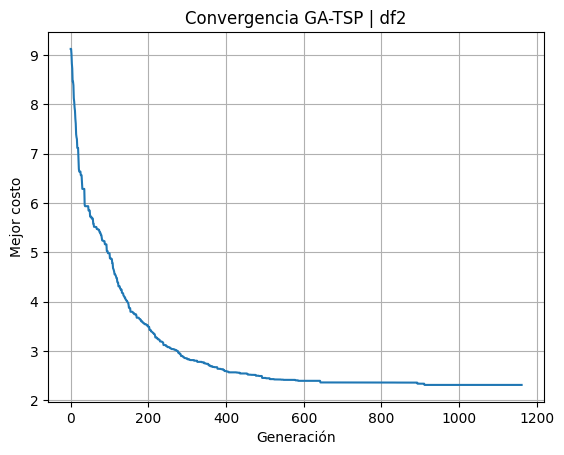

Mejor ruta (IDs): [145, 399, 5, 132, 111, 97, 95, 35, 61, 140, 100, 22, 90, 31, 142, 23, 93, 62, 105, 139, 0, 422, 301, 281, 272, 333, 376, 171, 336, 47, 87, 104, 302, 224, 199, 265, 405, 173, 384, 331, 189, 109, 190, 215, 119, 235, 206, 237, 346, 198, 285, 247, 391, 150, 154, 251, 264, 195, 204, 403, 349, 292, 219, 227, 298, 232, 220, 372, 297, 415, 296, 396, 223, 392, 213, 427, 325, 226, 370, 192, 33, 91, 280, 397, 123, 42, 389, 133, 41, 102, 121, 125, 64, 30, 69, 114, 53, 147, 73, 110]

=== Hoja 3 (df3) ===
Gen    1 | Best = 9.6027
Gen  100 | Best = 4.8347
Gen  200 | Best = 3.1945
Gen  300 | Best = 2.6578
Gen  400 | Best = 2.4231
Gen  500 | Best = 2.3160
Gen  600 | Best = 2.1388
Gen  700 | Best = 2.1175
Gen  800 | Best = 2.0814
Gen  900 | Best = 2.0383
Gen 1000 | Best = 2.0358
Gen 1100 | Best = 2.0358
Gen 1200 | Best = 2.0333
Tiempo total: 50.87s | Mejor costo = 2.0333


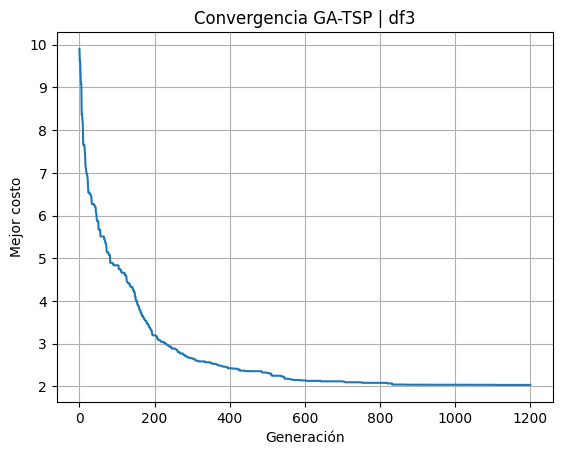

Mejor ruta (IDs): [257, 420, 123, 341, 76, 92, 105, 93, 10, 15, 127, 25, 95, 6, 53, 20, 136, 56, 16, 96, 80, 46, 125, 7, 379, 126, 131, 189, 190, 163, 304, 173, 268, 408, 265, 199, 398, 224, 266, 390, 373, 260, 415, 277, 165, 182, 204, 184, 178, 195, 274, 410, 255, 357, 377, 217, 159, 354, 247, 172, 259, 409, 285, 315, 387, 401, 310, 335, 407, 263, 267, 273, 203, 225, 297, 342, 279, 360, 234, 394, 253, 219, 393, 218, 233, 334, 347, 246, 239, 353, 174, 368, 278, 411, 350, 196, 242, 376, 245, 176]

=== Hoja 4 (df4) ===
Gen    1 | Best = 8.8909
Gen  100 | Best = 4.1618
Gen  200 | Best = 2.6310
Gen  300 | Best = 2.1426
Gen  400 | Best = 1.9900
Gen  500 | Best = 1.9458
Gen  600 | Best = 1.7965
Gen  700 | Best = 1.6925
Gen  800 | Best = 1.6324
Gen  900 | Best = 1.5952
Gen 1000 | Best = 1.5916
Gen 1100 | Best = 1.5639
Gen 1200 | Best = 1.5639
Tiempo total: 50.80s | Mejor costo = 1.5639


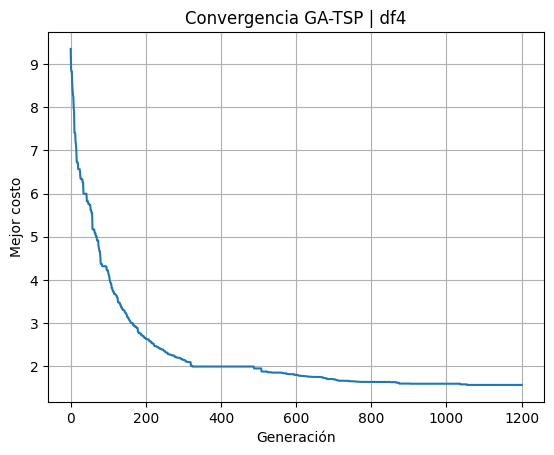

Mejor ruta (IDs): [343, 359, 393, 158, 254, 225, 157, 232, 371, 275, 296, 260, 347, 246, 392, 224, 162, 188, 257, 420, 245, 236, 213, 252, 353, 314, 319, 370, 418, 166, 317, 301, 177, 385, 328, 302, 313, 304, 378, 109, 72, 37, 131, 98, 103, 9, 26, 56, 49, 17, 126, 0, 341, 10, 55, 138, 97, 4, 35, 84, 114, 19, 22, 21, 140, 69, 96, 71, 125, 46, 102, 45, 120, 67, 116, 89, 28, 119, 395, 217, 404, 391, 172, 338, 269, 300, 315, 211, 186, 261, 369, 337, 154, 187, 276, 195, 324, 344, 322, 428]

=== Hoja 5 (df5) ===
Gen    1 | Best = 10.0834
Gen  100 | Best = 5.3430
Gen  200 | Best = 3.7876
Gen  300 | Best = 2.8820
Gen  400 | Best = 2.2767
Gen  500 | Best = 2.0850
Gen  600 | Best = 2.0372
Gen  700 | Best = 2.0172
Gen  800 | Best = 2.0138
Gen  900 | Best = 1.9978
Gen 1000 | Best = 1.9935
Gen 1100 | Best = 1.9935
Gen 1200 | Best = 1.9935
Tiempo total: 50.85s | Mejor costo = 1.9935


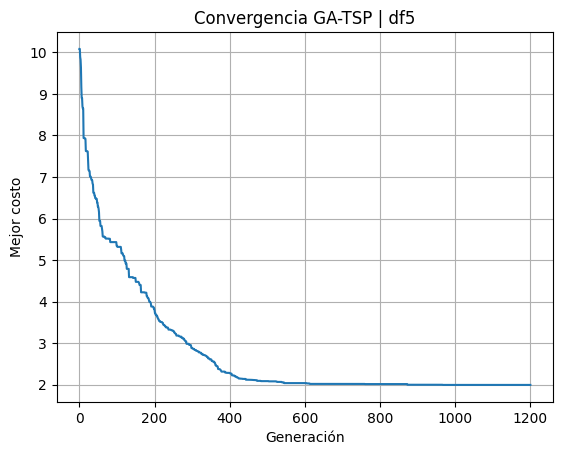

Mejor ruta (IDs): [268, 162, 336, 245, 74, 177, 301, 167, 420, 1, 57, 341, 139, 33, 422, 319, 278, 284, 281, 385, 113, 86, 98, 364, 75, 70, 93, 60, 44, 23, 128, 54, 95, 12, 55, 122, 61, 16, 38, 137, 41, 45, 107, 34, 28, 58, 36, 129, 89, 395, 375, 377, 248, 259, 216, 351, 247, 261, 229, 197, 150, 168, 290, 170, 155, 214, 274, 355, 330, 303, 164, 180, 423, 320, 344, 428, 403, 267, 349, 231, 254, 365, 286, 374, 298, 209, 358, 348, 218, 240, 275, 380, 390, 156, 250, 386, 153, 405, 408, 302]

=== Hoja 6 (df6) ===
Gen    1 | Best = 141.2248
Gen  100 | Best = 136.2078
Gen  200 | Best = 134.5938
Gen  300 | Best = 134.1063
Gen  400 | Best = 133.8792
Gen  500 | Best = 133.6993
Gen  600 | Best = 133.6327
Gen  700 | Best = 133.6083
Gen  800 | Best = 133.6083
Gen  900 | Best = 133.5866
Gen 1000 | Best = 133.5782
Gen 1100 | Best = 133.5782
Gen 1200 | Best = 133.5723
Tiempo total: 50.89s | Mejor costo = 133.5723


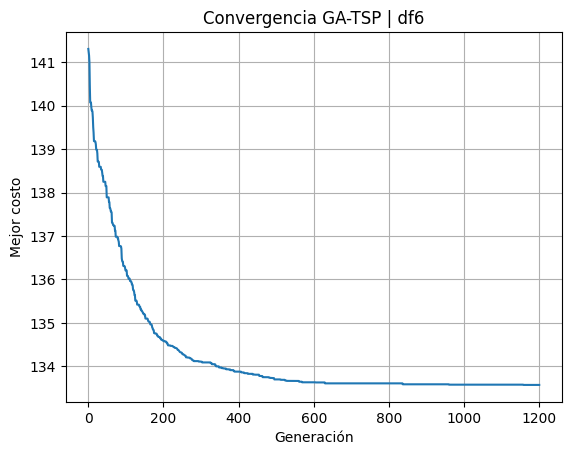

Mejor ruta (IDs): [344, 428, 407, 343, 152, 231, 243, 349, 219, 292, 225, 394, 253, 205, 309, 426, 425, 279, 240, 415, 165, 182, 313, 340, 265, 224, 249, 386, 239, 287, 412, 193, 325, 271, 321, 74, 181, 281, 77, 210, 27, 1, 0, 341, 148, 70, 111, 138, 146, 54, 66, 25, 142, 15, 31, 90, 21, 26, 145, 71, 96, 114, 84, 115, 338, 388, 198, 237, 357, 354, 401, 308, 187, 416, 170, 83, 414, 89, 141, 28, 36, 67, 41, 121, 125, 134, 389, 42, 106, 86, 87, 104, 131, 68, 378, 331, 274, 304, 183, 324]

=== Hoja 7 (df7) ===
Gen    1 | Best = 40.9181
Gen  100 | Best = 36.9058
Gen  200 | Best = 35.8293
Gen  300 | Best = 35.2376
Gen  400 | Best = 35.0930
Gen  500 | Best = 34.9775
Gen  600 | Best = 34.8946
Gen  700 | Best = 34.8054
Gen  800 | Best = 34.7357
Gen  900 | Best = 34.6526
Gen 1000 | Best = 34.6056
Gen 1100 | Best = 34.5670
Gen 1200 | Best = 34.5668
Tiempo total: 50.76s | Mejor costo = 34.5668


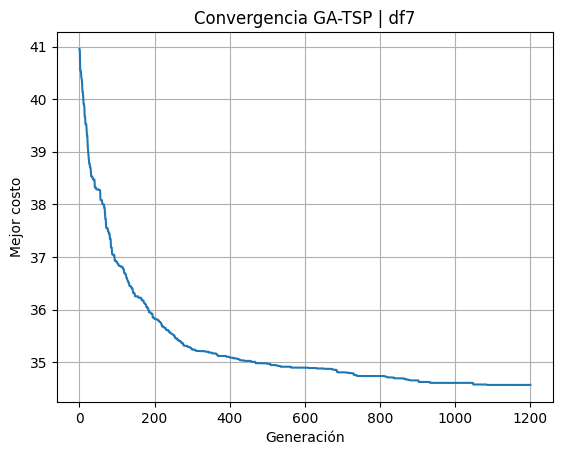

Mejor ruta (IDs): [428, 343, 212, 254, 365, 275, 342, 218, 424, 179, 8, 76, 79, 2, 88, 281, 245, 176, 333, 272, 193, 236, 188, 87, 113, 47, 328, 340, 268, 200, 405, 224, 249, 293, 386, 373, 240, 417, 396, 323, 164, 180, 329, 117, 14, 37, 72, 18, 98, 126, 59, 62, 15, 55, 12, 39, 35, 85, 114, 101, 135, 147, 22, 136, 143, 132, 49, 110, 9, 134, 75, 11, 108, 379, 34, 364, 102, 133, 116, 52, 89, 395, 215, 346, 356, 315, 261, 369, 168, 150, 416, 170, 264, 159, 404, 299, 335, 324, 182, 165]

=== Hoja 8 (df8) ===
Gen    1 | Best = 8.6164
Gen  100 | Best = 4.7786
Gen  200 | Best = 2.6576
Gen  300 | Best = 2.0014
Gen  400 | Best = 1.7698
Gen  500 | Best = 1.6911
Gen  600 | Best = 1.6881
Gen  700 | Best = 1.6646
Gen  800 | Best = 1.6613
Gen  900 | Best = 1.6613
Paro por paciencia en gen 957 (best = 1.6613)
Tiempo total: 40.94s | Mejor costo = 1.6613


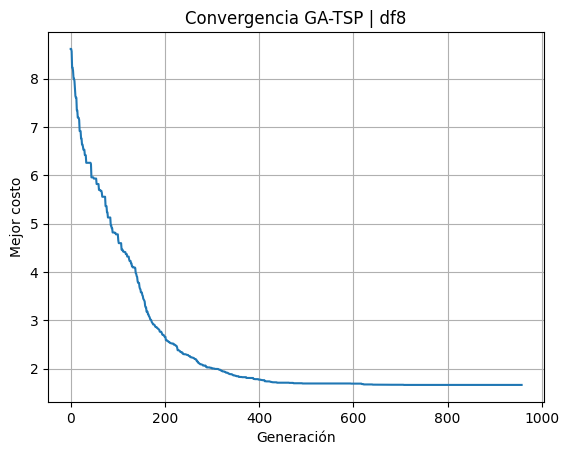

Mejor ruta (IDs): [336, 398, 249, 363, 239, 156, 222, 227, 394, 209, 231, 349, 343, 152, 426, 220, 256, 305, 322, 184, 150, 154, 229, 261, 387, 175, 172, 248, 259, 338, 356, 160, 315, 151, 308, 291, 290, 416, 310, 295, 214, 264, 354, 357, 237, 375, 45, 65, 52, 410, 221, 189, 238, 329, 320, 323, 265, 200, 72, 68, 131, 379, 11, 108, 86, 43, 27, 0, 148, 132, 143, 13, 80, 140, 55, 54, 66, 23, 10, 105, 341, 78, 33, 271, 370, 278, 368, 424, 353, 333, 171, 242, 350, 397, 307, 317, 411, 316, 245, 382]

=== Hoja 9 (df9) ===
Gen    1 | Best = 141.0317
Gen  100 | Best = 136.9480
Gen  200 | Best = 135.0777
Gen  300 | Best = 134.3781
Gen  400 | Best = 134.0181
Gen  500 | Best = 133.8263
Gen  600 | Best = 133.7418
Gen  700 | Best = 133.7251
Gen  800 | Best = 133.6353
Gen  900 | Best = 133.5955
Gen 1000 | Best = 133.5955
Gen 1100 | Best = 133.5873
Gen 1200 | Best = 133.5502
Tiempo total: 51.25s | Mejor costo = 133.5502


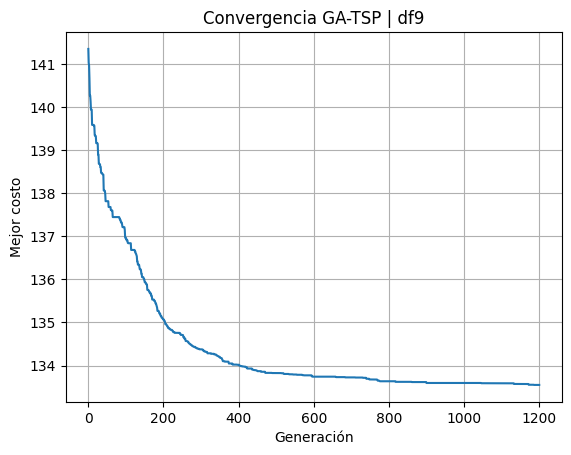

Mejor ruta (IDs): [339, 224, 353, 334, 311, 328, 382, 188, 196, 47, 210, 397, 177, 385, 317, 179, 424, 325, 284, 418, 92, 341, 10, 23, 66, 54, 122, 19, 85, 53, 3, 80, 115, 46, 45, 107, 364, 11, 51, 136, 132, 49, 59, 123, 126, 108, 389, 131, 262, 109, 283, 238, 190, 163, 330, 244, 191, 384, 221, 215, 255, 410, 159, 404, 217, 237, 248, 186, 211, 300, 216, 198, 388, 155, 369, 289, 290, 151, 288, 263, 413, 352, 243, 212, 219, 253, 367, 205, 362, 371, 202, 305, 277, 396, 400, 363, 347, 386, 200, 408]

=== Hoja 10 (df10) ===
Gen    1 | Best = 41.9064
Gen  100 | Best = 37.2368
Gen  200 | Best = 36.3240
Gen  300 | Best = 35.3413
Gen  400 | Best = 35.0223
Gen  500 | Best = 34.8040
Gen  600 | Best = 34.6743
Gen  700 | Best = 34.6743
Gen  800 | Best = 34.6603
Gen  900 | Best = 34.6603
Gen 1000 | Best = 34.6581
Gen 1100 | Best = 34.6581
Gen 1200 | Best = 34.6581
Tiempo total: 50.73s | Mejor costo = 34.6581


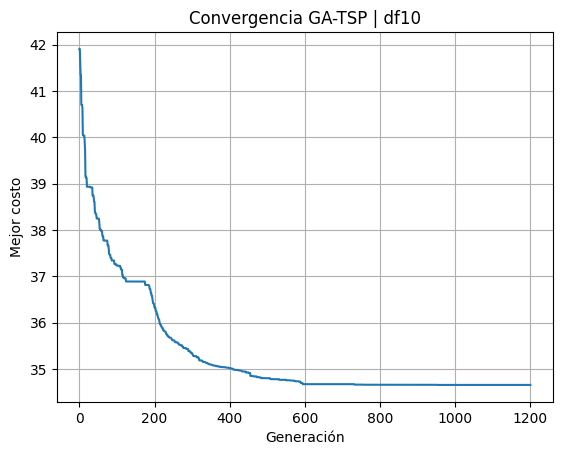

Mejor ruta (IDs): [12, 100, 75, 65, 58, 255, 361, 402, 117, 183, 184, 297, 286, 425, 232, 371, 362, 234, 298, 209, 383, 273, 203, 158, 208, 250, 199, 224, 381, 252, 386, 241, 412, 319, 230, 278, 306, 422, 181, 8, 76, 105, 23, 60, 62, 57, 27, 48, 124, 307, 74, 245, 77, 210, 113, 47, 350, 196, 265, 339, 390, 417, 305, 323, 299, 404, 170, 416, 187, 308, 290, 168, 154, 337, 351, 198, 300, 285, 116, 141, 399, 98, 364, 16, 11, 118, 42, 17, 24, 29, 81, 94, 15, 136, 21, 13, 85, 39, 54, 25]


,sheet,best_cost,n
0,df1,2.464475,100
1,df10,34.658098,100
2,df2,2.310893,100
3,df3,2.033266,100
4,df4,1.563881,100
5,df5,1.993544,100
6,df6,133.572320,100
7,df7,34.566831,100
8,df8,1.661309,100
9,df9,133.550180,100


,sheet,route_ids,length_nodes
0,df1,411->282->181->92->332->97->146->111->21->143-...,100
1,df10,12->100->75->65->58->255->361->402->117->183->...,100
2,df2,145->399->5->132->111->97->95->35->61->140->10...,100
3,df3,257->420->123->341->76->92->105->93->10->15->1...,100
4,df4,343->359->393->158->254->225->157->232->371->2...,100
5,df5,268->162->336->245->74->177->301->167->420->1-...,100
6,df6,344->428->407->343->152->231->243->349->219->2...,100
7,df7,428->343->212->254->365->275->342->218->424->1...,100
8,df8,336->398->249->363->239->156->222->227->394->2...,100
9,df9,339->224->353->334->311->328->382->188->196->4...,100


Guardados: tsp_ga_results_summary.csv, tsp_ga_best_routes_ids.csv


In [ ]:
GA_PARAMS = dict(
    pop_size=220,
    generations=1200,
    elite_size=2,
    tournament_k=3,
    mutation_prob=0.25,
    crossover_perc=1.0,
    patience=250,
    seed=123,
    verbose=True
)

all_results = []
routes_rows = []

for i, df in enumerate(dfs, start=1):
    print(f"\n=== Hoja {i} (df{i}) ===")
    dist, labels = to_distance_matrix_with_labels(df)
    route, cost, hist = ga_tsp(dist, **GA_PARAMS)
    all_results.append({"sheet": f"df{i}", "best_cost": cost, "n": dist.shape[0]})
    routes_rows.append({
        "sheet": f"df{i}",
        "route_ids": "->".join(map(str, route_to_labels(route, labels))),
        "length_nodes": len(route)
    })
    plot_history(hist, title=f"Convergencia GA-TSP | df{i}")
    print("Mejor ruta (IDs):", route_to_labels(route, labels))

res_df = pd.DataFrame(all_results).sort_values("sheet").reset_index(drop=True)
routes_df = pd.DataFrame(routes_rows).sort_values("sheet").reset_index(drop=True)

display(res_df)
display(routes_df)

res_df.to_csv("tsp_ga_results_summary.csv", index=False)
routes_df.to_csv("tsp_ga_best_routes_ids.csv", index=False)
print("Guardados: tsp_ga_results_summary.csv, tsp_ga_best_routes_ids.csv")

In [ ]:
import io, numpy as np, pandas as pd
from google.colab import files

uploaded = files.upload()
xlsx_name = list(uploaded.keys())[0]
xlsx_bytes = io.BytesIO(uploaded[xlsx_name])

xls = pd.ExcelFile(xlsx_bytes)
sheet_names = xls.sheet_names

globals_dict = globals()
dfs = []
labels_list = []

for i, sh in enumerate(sheet_names, start=1):
    df = pd.read_excel(xls, sheet_name=sh, header=0, index_col=0)
    df = df.apply(pd.to_numeric, errors='coerce').fillna(np.inf)

    var_name = f"df{i}"
    globals_dict[var_name] = df
    dfs.append(df)
    labels_list.append(df.index.tolist())

    print(f"{var_name} cargado (hoja='{sh}', shape={df.shape})")

print(f"\nTotal hojas leídas: {len(dfs)}")

Saving matrices_150.xlsx to matrices_150.xlsx
df1 cargado (hoja='Instancia_1', shape=(150, 150))
df2 cargado (hoja='Instancia_2', shape=(150, 150))
df3 cargado (hoja='Instancia_3', shape=(150, 150))
df4 cargado (hoja='Instancia_4', shape=(150, 150))
df5 cargado (hoja='Instancia_5', shape=(150, 150))
df6 cargado (hoja='Instancia_6', shape=(150, 150))
df7 cargado (hoja='Instancia_7', shape=(150, 150))
df8 cargado (hoja='Instancia_8', shape=(150, 150))
df9 cargado (hoja='Instancia_9', shape=(150, 150))
df10 cargado (hoja='Instancia_10', shape=(150, 150))

Total hojas leídas: 10



=== Hoja 1 (df1) ===
Gen    1 | Best = 146.6985
Gen  100 | Best = 139.8038
Gen  200 | Best = 137.5521
Gen  300 | Best = 136.3237
Gen  400 | Best = 135.7167
Gen  500 | Best = 135.3180
Gen  600 | Best = 135.0083
Gen  700 | Best = 134.6993
Gen  800 | Best = 134.6908
Gen  900 | Best = 134.6330
Gen 1000 | Best = 134.6069
Gen 1100 | Best = 134.5681
Gen 1200 | Best = 134.5249
Tiempo total: 100.32s | Mejor costo = 134.5249


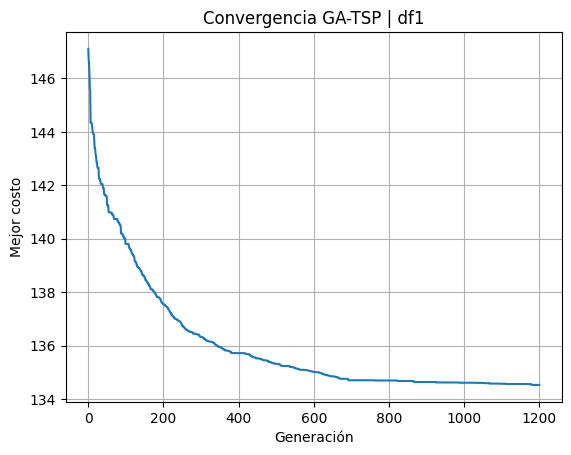

Mejor ruta (IDs): [215, 270, 274, 238, 189, 283, 199, 293, 174, 427, 381, 287, 376, 382, 316, 325, 424, 185, 228, 278, 230, 418, 332, 91, 33, 282, 317, 301, 242, 350, 47, 87, 82, 104, 68, 98, 37, 86, 106, 108, 399, 107, 141, 28, 7, 379, 75, 73, 96, 114, 100, 21, 29, 56, 49, 24, 1, 57, 92, 124, 0, 201, 93, 60, 81, 23, 40, 138, 4, 35, 6, 115, 137, 38, 63, 41, 120, 144, 52, 119, 361, 375, 409, 198, 269, 388, 172, 351, 247, 401, 229, 154, 308, 294, 369, 168, 276, 264, 414, 323, 178, 184, 204, 165, 322, 305, 360, 203, 413, 209, 273, 349, 205, 208, 345, 219, 253, 359, 393, 298, 394, 426, 157, 169, 260, 390, 296, 279, 380, 419, 362, 220, 372, 371, 403, 83, 155, 251, 289, 186, 211, 300, 216, 206, 235, 89, 117, 423, 173, 395]

=== Hoja 2 (df2) ===
Gen    1 | Best = 14.8785
Gen  100 | Best = 8.3144
Gen  200 | Best = 6.3718
Gen  300 | Best = 4.5334
Gen  400 | Best = 3.6596
Gen  500 | Best = 3.2158
Gen  600 | Best = 2.8918
Gen  700 | Best = 2.7470
Gen  800 | Best = 2.6642
Gen  900 | Best = 2.5259


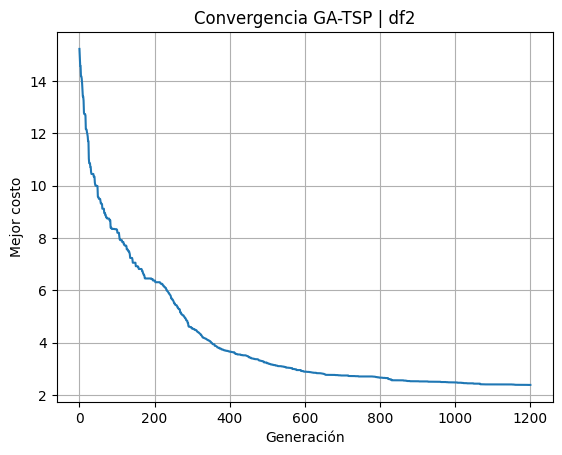

Mejor ruta (IDs): [412, 88, 1, 93, 60, 44, 94, 40, 12, 95, 31, 128, 146, 4, 84, 19, 22, 20, 143, 56, 29, 3, 71, 16, 73, 110, 5, 126, 103, 104, 131, 18, 98, 389, 112, 364, 64, 102, 120, 133, 144, 107, 141, 36, 235, 361, 375, 300, 175, 211, 326, 172, 248, 356, 198, 409, 206, 217, 155, 391, 261, 229, 150, 308, 187, 170, 404, 335, 324, 204, 184, 305, 279, 256, 202, 419, 169, 367, 345, 358, 227, 352, 349, 413, 383, 273, 403, 267, 343, 292, 253, 359, 393, 158, 234, 362, 220, 165, 183, 384, 215, 270, 355, 255, 329, 378, 189, 109, 405, 153, 258, 293, 246, 156, 233, 386, 353, 427, 381, 333, 171, 328, 350, 257, 280, 341, 139, 79, 148, 201, 78, 76, 8, 91, 33, 271, 319, 370, 306, 418, 366, 185, 228, 325, 179, 411, 177, 242, 188, 311]

=== Hoja 3 (df3) ===
Gen    1 | Best = 14.4521
Gen  100 | Best = 8.2849
Gen  200 | Best = 5.9878
Gen  300 | Best = 4.6334
Gen  400 | Best = 3.8167
Gen  500 | Best = 3.3986
Gen  600 | Best = 3.1073
Gen  700 | Best = 2.8139
Gen  800 | Best = 2.6591
Gen  900 | Best = 2.

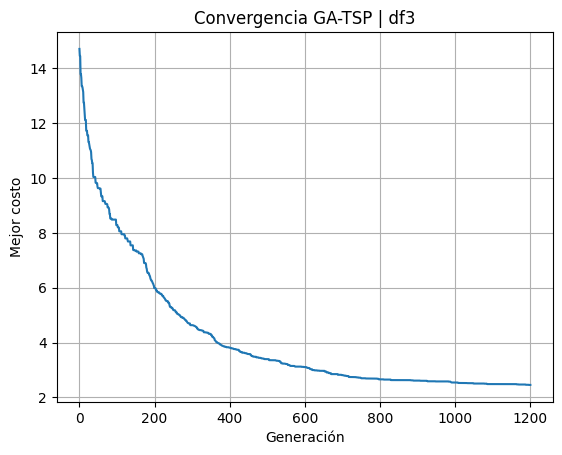

Mejor ruta (IDs): [43, 1, 118, 389, 125, 107, 58, 52, 120, 46, 30, 51, 140, 114, 84, 122, 95, 4, 54, 128, 44, 81, 138, 12, 22, 100, 20, 136, 29, 49, 59, 257, 210, 196, 350, 176, 124, 57, 0, 148, 70, 60, 105, 79, 341, 78, 8, 161, 177, 271, 179, 370, 418, 226, 284, 228, 245, 376, 193, 241, 427, 252, 386, 207, 233, 266, 258, 293, 340, 339, 162, 268, 68, 313, 283, 329, 109, 164, 303, 331, 163, 190, 410, 255, 377, 414, 323, 182, 165, 417, 415, 222, 380, 279, 202, 256, 362, 365, 292, 225, 394, 298, 374, 158, 253, 219, 212, 349, 383, 343, 157, 372, 360, 288, 263, 428, 305, 344, 324, 178, 195, 310, 416, 308, 291, 168, 151, 337, 369, 391, 155, 354, 216, 312, 326, 351, 315, 186, 269, 285, 409, 361, 36, 141, 119, 262, 364, 98, 72, 106]

=== Hoja 4 (df4) ===
Gen    1 | Best = 159.3799
Gen  100 | Best = 151.4660
Gen  200 | Best = 148.7519
Gen  300 | Best = 147.3818
Gen  400 | Best = 146.5183
Gen  500 | Best = 146.1642
Gen  600 | Best = 146.1062
Gen  700 | Best = 145.6849
Gen  800 | Best = 145.6046


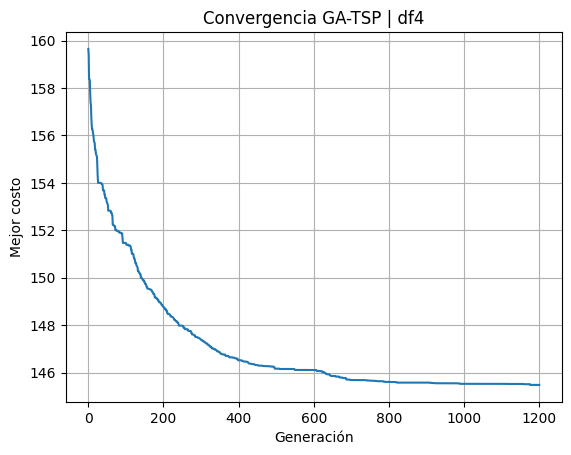

Mejor ruta (IDs): [238, 14, 423, 313, 72, 103, 86, 43, 123, 59, 27, 280, 257, 316, 236, 193, 376, 382, 77, 245, 176, 177, 301, 321, 282, 74, 307, 281, 412, 174, 284, 166, 179, 306, 33, 91, 2, 0, 70, 29, 75, 73, 145, 100, 114, 61, 85, 122, 4, 146, 95, 54, 127, 25, 142, 31, 23, 44, 60, 93, 139, 92, 32, 332, 39, 115, 46, 63, 30, 64, 125, 364, 130, 89, 116, 121, 102, 41, 133, 375, 170, 299, 215, 395, 355, 191, 384, 414, 323, 178, 182, 305, 419, 202, 275, 425, 372, 157, 256, 169, 348, 345, 208, 227, 219, 225, 362, 365, 243, 349, 352, 231, 253, 309, 252, 258, 390, 224, 398, 353, 427, 213, 287, 314, 241, 415, 322, 288, 403, 428, 151, 290, 416, 149, 261, 247, 175, 351, 315, 160, 285, 338, 356, 198, 248, 172, 391, 214, 404, 320]

=== Hoja 5 (df5) ===
Gen    1 | Best = 146.2794
Gen  100 | Best = 140.1920
Gen  200 | Best = 137.8339
Gen  300 | Best = 136.6568
Gen  400 | Best = 135.9437
Gen  500 | Best = 135.5694
Gen  600 | Best = 135.1769
Gen  700 | Best = 134.9221
Gen  800 | Best = 134.7941
Gen  

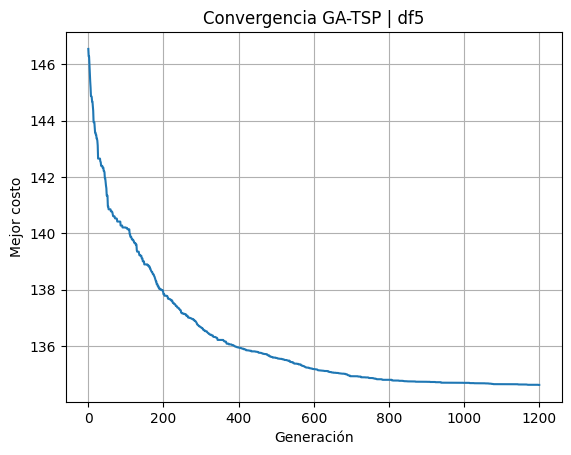

Mejor ruta (IDs): [378, 173, 190, 163, 330, 299, 404, 310, 327, 151, 150, 197, 251, 387, 186, 211, 312, 259, 357, 270, 395, 36, 133, 45, 115, 38, 41, 120, 34, 112, 7, 379, 134, 26, 126, 43, 302, 405, 199, 258, 224, 398, 339, 223, 322, 417, 380, 279, 157, 372, 297, 152, 352, 383, 273, 267, 288, 371, 286, 234, 298, 227, 358, 218, 367, 169, 222, 277, 260, 334, 400, 386, 252, 246, 213, 287, 174, 311, 376, 193, 284, 226, 366, 370, 278, 306, 192, 33, 32, 341, 139, 90, 44, 15, 127, 138, 66, 97, 122, 6, 84, 35, 53, 85, 22, 140, 3, 71, 73, 145, 136, 29, 132, 59, 123, 280, 167, 201, 91, 181, 307, 177, 281, 77, 316, 350, 336, 113, 131, 389, 72, 130, 67, 116, 129, 50, 119, 346, 216, 248, 247, 261, 170, 274, 423, 109, 402, 14, 117, 329]

=== Hoja 6 (df6) ===
Gen    1 | Best = 15.2584
Gen  100 | Best = 8.3570
Gen  200 | Best = 6.3812
Gen  300 | Best = 4.8677
Gen  400 | Best = 3.9865
Gen  500 | Best = 3.4881
Gen  600 | Best = 3.2915
Gen  700 | Best = 3.2028
Gen  800 | Best = 3.1023
Gen  900 | Best = 

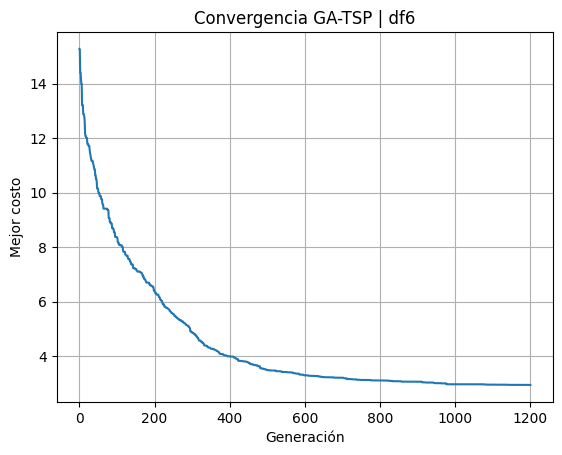

Mejor ruta (IDs): [265, 153, 200, 173, 183, 322, 277, 380, 417, 240, 279, 342, 425, 372, 297, 362, 234, 393, 359, 365, 152, 403, 267, 349, 383, 413, 209, 367, 205, 218, 348, 358, 192, 32, 91, 8, 78, 79, 62, 10, 94, 70, 132, 29, 24, 56, 143, 9, 364, 30, 137, 116, 52, 89, 7, 389, 103, 106, 18, 87, 37, 117, 238, 189, 384, 304, 215, 410, 395, 237, 214, 388, 216, 198, 300, 326, 369, 294, 151, 149, 291, 187, 310, 335, 323, 182, 250, 396, 222, 386, 213, 194, 293, 199, 340, 311, 287, 241, 333, 376, 171, 196, 350, 167, 181, 422, 179, 368, 284, 166, 177, 161, 317, 301, 307, 257, 88, 57, 341, 93, 90, 138, 12, 95, 4, 84, 53, 85, 61, 114, 101, 100, 13, 134, 399, 67, 120, 41, 361, 235, 357, 270, 255, 217, 274, 303, 414, 163, 221, 313]

=== Hoja 7 (df7) ===
Gen    1 | Best = 13.2741
Gen  100 | Best = 7.8534
Gen  200 | Best = 5.2362
Gen  300 | Best = 4.0799
Gen  400 | Best = 3.4029
Gen  500 | Best = 3.0206
Gen  600 | Best = 2.6205
Gen  700 | Best = 2.4101
Gen  800 | Best = 2.2707
Gen  900 | Best = 2.1

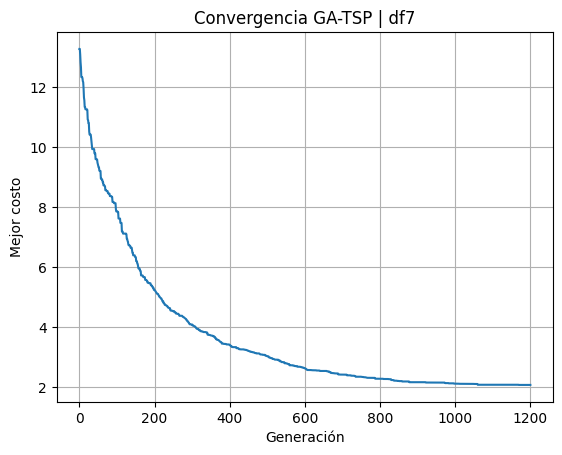

Mejor ruta (IDs): [265, 340, 104, 118, 42, 98, 68, 14, 109, 355, 330, 274, 163, 304, 117, 189, 238, 320, 384, 178, 204, 195, 159, 214, 248, 172, 401, 197, 154, 310, 416, 290, 291, 247, 326, 175, 285, 346, 377, 217, 270, 215, 235, 116, 52, 58, 120, 41, 102, 46, 30, 107, 112, 7, 399, 11, 5, 126, 123, 24, 49, 56, 145, 73, 16, 71, 100, 140, 61, 85, 12, 128, 142, 90, 44, 15, 23, 105, 62, 70, 1, 27, 43, 336, 188, 196, 257, 397, 167, 124, 48, 57, 341, 78, 201, 92, 33, 321, 74, 317, 161, 316, 245, 421, 385, 333, 411, 319, 306, 370, 166, 226, 228, 185, 284, 348, 218, 227, 158, 254, 298, 212, 349, 383, 343, 152, 157, 365, 360, 309, 279, 275, 305, 184, 318, 324, 182, 415, 400, 223, 252, 381, 427, 213, 239, 246, 207, 392, 153, 224]

=== Hoja 8 (df8) ===
Gen    1 | Best = 146.4225
Gen  100 | Best = 140.3788
Gen  200 | Best = 137.6631
Gen  300 | Best = 136.2447
Gen  400 | Best = 135.5836
Gen  500 | Best = 135.2523
Gen  600 | Best = 135.0437
Gen  700 | Best = 134.8134
Gen  800 | Best = 134.6945
Gen  

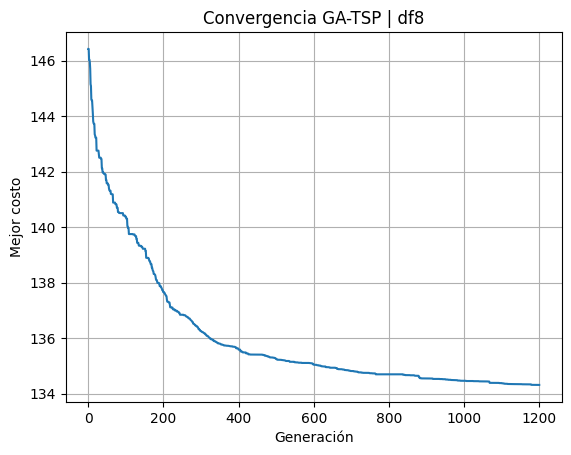

Mejor ruta (IDs): [333, 314, 427, 392, 347, 373, 239, 233, 156, 222, 309, 367, 345, 352, 243, 273, 212, 393, 298, 374, 158, 394, 267, 403, 288, 220, 342, 182, 324, 318, 195, 83, 290, 149, 337, 387, 326, 175, 300, 375, 361, 235, 377, 217, 395, 410, 402, 14, 86, 87, 162, 199, 340, 398, 390, 363, 258, 339, 265, 302, 408, 200, 189, 117, 329, 384, 270, 357, 295, 391, 155, 310, 276, 150, 168, 289, 197, 369, 247, 172, 259, 160, 115, 101, 114, 135, 53, 85, 84, 95, 97, 54, 66, 25, 23, 138, 55, 22, 100, 71, 145, 9, 364, 28, 50, 129, 36, 52, 67, 45, 102, 137, 64, 379, 108, 106, 126, 123, 24, 81, 62, 76, 78, 48, 124, 280, 257, 420, 210, 171, 385, 316, 161, 307, 301, 181, 282, 411, 422, 321, 33, 192, 418, 366, 278, 284, 228, 376, 311, 236]

=== Hoja 9 (df9) ===
Gen    1 | Best = 147.4464
Gen  100 | Best = 140.3580
Gen  200 | Best = 137.9372
Gen  300 | Best = 136.4443
Gen  400 | Best = 135.6293
Gen  500 | Best = 135.2858
Gen  600 | Best = 135.1080
Gen  700 | Best = 134.9301
Gen  800 | Best = 134.793

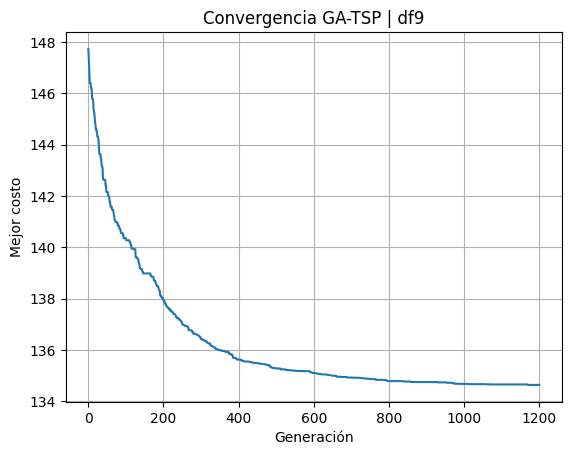

Mejor ruta (IDs): [61, 84, 122, 22, 21, 93, 10, 44, 90, 23, 25, 54, 97, 4, 35, 19, 140, 3, 80, 134, 364, 45, 116, 50, 330, 238, 72, 42, 126, 123, 43, 106, 103, 24, 75, 399, 64, 30, 115, 46, 41, 144, 141, 361, 216, 351, 186, 387, 409, 172, 261, 187, 168, 289, 401, 391, 155, 237, 404, 354, 270, 215, 262, 378, 180, 173, 283, 320, 221, 335, 183, 318, 344, 178, 204, 165, 415, 156, 222, 380, 419, 348, 358, 208, 345, 298, 394, 253, 212, 349, 383, 267, 263, 407, 220, 362, 286, 157, 372, 297, 426, 360, 279, 396, 296, 194, 398, 328, 385, 77, 272, 171, 258, 224, 339, 265, 405, 406, 260, 373, 246, 233, 386, 287, 241, 314, 325, 332, 192, 370, 179, 230, 319, 411, 281, 245, 167, 280, 307, 301, 282, 33, 91, 8, 161, 48, 78, 79, 55, 147]

=== Hoja 10 (df10) ===
Gen    1 | Best = 14.6837
Gen  100 | Best = 8.6966
Gen  200 | Best = 6.4648
Gen  300 | Best = 4.8301
Gen  400 | Best = 4.1241
Gen  500 | Best = 3.6096
Gen  600 | Best = 3.2531
Gen  700 | Best = 3.1361
Gen  800 | Best = 3.0095
Gen  900 | Best = 2.

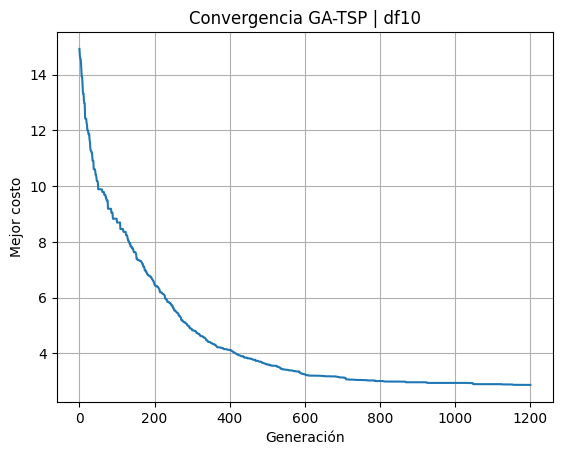

Mejor ruta (IDs): [67, 361, 217, 346, 388, 206, 312, 186, 351, 315, 211, 175, 160, 216, 172, 401, 295, 414, 191, 238, 304, 173, 323, 164, 68, 402, 89, 375, 357, 261, 197, 149, 187, 151, 290, 214, 330, 355, 221, 313, 423, 189, 131, 37, 18, 262, 268, 265, 406, 250, 156, 207, 194, 392, 246, 296, 380, 305, 288, 403, 267, 263, 343, 273, 231, 359, 367, 393, 394, 362, 425, 286, 157, 275, 279, 202, 419, 165, 390, 258, 153, 213, 427, 241, 174, 376, 171, 328, 336, 99, 59, 123, 57, 167, 74, 33, 332, 306, 230, 366, 319, 271, 281, 245, 350, 196, 104, 82, 43, 106, 103, 42, 118, 364, 130, 389, 11, 75, 110, 56, 136, 85, 55, 138, 40, 90, 94, 10, 62, 201, 92, 139, 79, 23, 142, 97, 146, 6, 61, 69, 96, 71, 125, 30, 46, 63, 102, 120, 36, 65]


,sheet,best_cost,n
0,df1,134.524941,150
1,df10,2.870533,150
2,df2,2.386643,150
3,df3,2.456216,150
4,df4,145.478770,150
5,df5,134.612474,150
6,df6,2.939793,150
7,df7,2.065252,150
8,df8,134.312079,150
9,df9,134.643142,150


,sheet,route_ids,length_nodes
0,df1,215->270->274->238->189->283->199->293->174->4...,150
1,df10,67->361->217->346->388->206->312->186->351->31...,150
2,df2,412->88->1->93->60->44->94->40->12->95->31->12...,150
3,df3,43->1->118->389->125->107->58->52->120->46->30...,150
4,df4,238->14->423->313->72->103->86->43->123->59->2...,150
5,df5,378->173->190->163->330->299->404->310->327->1...,150
6,df6,265->153->200->173->183->322->277->380->417->2...,150
7,df7,265->340->104->118->42->98->68->14->109->355->...,150
8,df8,333->314->427->392->347->373->239->233->156->2...,150
9,df9,61->84->122->22->21->93->10->44->90->23->25->5...,150


Guardados: tsp_ga_results_summary.csv, tsp_ga_best_routes_ids.csv


In [ ]:
GA_PARAMS = dict(
    pop_size=220,
    generations=1200,
    elite_size=2,
    tournament_k=3,
    mutation_prob=0.25,
    crossover_perc=1.0,
    patience=250,
    seed=123,
    verbose=True
)

all_results = []
routes_rows = []

for i, df in enumerate(dfs, start=1):
    print(f"\n=== Hoja {i} (df{i}) ===")
    dist, labels = to_distance_matrix_with_labels(df)
    route, cost, hist = ga_tsp(dist, **GA_PARAMS)
    all_results.append({"sheet": f"df{i}", "best_cost": cost, "n": dist.shape[0]})
    routes_rows.append({
        "sheet": f"df{i}",
        "route_ids": "->".join(map(str, route_to_labels(route, labels))),
        "length_nodes": len(route)
    })
    plot_history(hist, title=f"Convergencia GA-TSP | df{i}")
    print("Mejor ruta (IDs):", route_to_labels(route, labels))

res_df = pd.DataFrame(all_results).sort_values("sheet").reset_index(drop=True)
routes_df = pd.DataFrame(routes_rows).sort_values("sheet").reset_index(drop=True)

display(res_df)
display(routes_df)

res_df.to_csv("tsp_ga_results_summary.csv", index=False)
routes_df.to_csv("tsp_ga_best_routes_ids.csv", index=False)
print("Guardados: tsp_ga_results_summary.csv, tsp_ga_best_routes_ids.csv")

In [ ]:
import io, numpy as np, pandas as pd
from google.colab import files

uploaded = files.upload()
xlsx_name = list(uploaded.keys())[0]
xlsx_bytes = io.BytesIO(uploaded[xlsx_name])

xls = pd.ExcelFile(xlsx_bytes)
sheet_names = xls.sheet_names

globals_dict = globals()
dfs = []
labels_list = []

for i, sh in enumerate(sheet_names, start=1):
    df = pd.read_excel(xls, sheet_name=sh, header=0, index_col=0)
    df = df.apply(pd.to_numeric, errors='coerce').fillna(np.inf)

    var_name = f"df{i}"
    globals_dict[var_name] = df
    dfs.append(df)
    labels_list.append(df.index.tolist())

    print(f"{var_name} cargado (hoja='{sh}', shape={df.shape})")

print(f"\nTotal hojas leídas: {len(dfs)}")

Saving matrices_200.xlsx to matrices_200.xlsx
df1 cargado (hoja='Instancia_1', shape=(200, 200))
df2 cargado (hoja='Instancia_2', shape=(200, 200))
df3 cargado (hoja='Instancia_3', shape=(200, 200))
df4 cargado (hoja='Instancia_4', shape=(200, 200))
df5 cargado (hoja='Instancia_5', shape=(200, 200))
df6 cargado (hoja='Instancia_6', shape=(200, 200))
df7 cargado (hoja='Instancia_7', shape=(200, 200))
df8 cargado (hoja='Instancia_8', shape=(200, 200))
df9 cargado (hoja='Instancia_9', shape=(200, 200))
df10 cargado (hoja='Instancia_10', shape=(200, 200))

Total hojas leídas: 10



=== Hoja 1 (df1) ===
Gen    1 | Best = 19.3750
Gen  100 | Best = 11.9572
Gen  200 | Best = 9.4265
Gen  300 | Best = 7.8333
Gen  400 | Best = 6.2877
Gen  500 | Best = 5.5715
Gen  600 | Best = 4.7406
Gen  700 | Best = 4.3494
Gen  800 | Best = 3.7680
Gen  900 | Best = 3.5209
Gen 1000 | Best = 3.3551
Gen 1100 | Best = 3.1866
Gen 1200 | Best = 3.1276
Tiempo total: 167.80s | Mejor costo = 3.1276


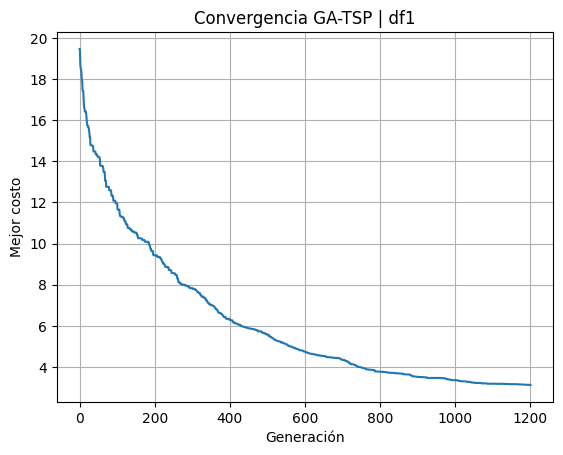

Mejor ruta (IDs): [346, 269, 198, 160, 356, 248, 312, 326, 211, 387, 401, 289, 308, 291, 149, 276, 354, 251, 186, 261, 294, 416, 310, 83, 274, 330, 163, 190, 244, 191, 238, 329, 109, 378, 320, 283, 313, 178, 184, 263, 407, 209, 359, 393, 394, 225, 343, 365, 254, 298, 374, 362, 360, 286, 425, 372, 297, 275, 240, 417, 415, 156, 400, 396, 322, 305, 256, 169, 208, 345, 367, 348, 246, 392, 194, 153, 266, 250, 406, 252, 287, 174, 193, 171, 333, 77, 74, 317, 301, 422, 33, 306, 418, 319, 228, 284, 226, 366, 424, 325, 411, 282, 91, 92, 341, 57, 62, 148, 23, 127, 81, 44, 10, 93, 70, 56, 145, 134, 364, 107, 130, 262, 119, 36, 58, 144, 67, 120, 41, 38, 121, 45, 133, 129, 402, 14, 131, 34, 399, 103, 106, 108, 389, 26, 100, 85, 19, 138, 40, 55, 12, 95, 146, 4, 122, 84, 53, 135, 71, 51, 143, 24, 99, 59, 123, 27, 307, 88, 124, 420, 257, 210, 126, 43, 188, 382, 328, 293, 199, 224, 302, 268, 408, 339, 340, 423, 117, 164, 173, 183, 335, 404, 410, 215, 395, 375, 361, 235, 217, 237]

=== Hoja 2 (df2) ===
G

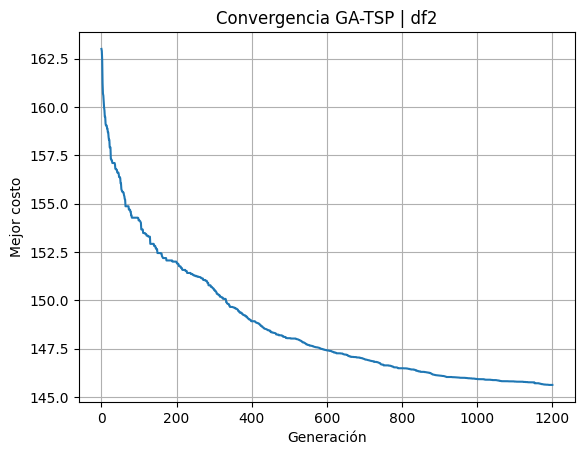

Mejor ruta (IDs): [213, 392, 194, 252, 386, 207, 233, 296, 260, 415, 277, 363, 406, 224, 293, 302, 268, 405, 199, 266, 223, 417, 240, 425, 426, 157, 275, 279, 297, 298, 253, 367, 208, 345, 348, 273, 243, 413, 209, 393, 220, 286, 372, 371, 165, 322, 178, 344, 288, 151, 168, 290, 308, 401, 154, 337, 261, 186, 172, 216, 346, 377, 217, 214, 299, 274, 323, 335, 276, 295, 391, 155, 159, 89, 131, 402, 109, 189, 262, 235, 285, 356, 206, 215, 331, 163, 304, 384, 180, 162, 408, 200, 104, 113, 336, 328, 196, 188, 382, 176, 317, 301, 167, 27, 88, 48, 341, 0, 62, 70, 136, 26, 132, 10, 148, 2, 32, 33, 92, 78, 201, 105, 111, 31, 15, 60, 90, 40, 66, 25, 55, 12, 122, 97, 6, 101, 3, 140, 135, 147, 100, 19, 85, 61, 39, 115, 63, 30, 64, 121, 102, 34, 120, 52, 375, 119, 50, 141, 130, 364, 7, 379, 108, 75, 16, 51, 134, 73, 13, 9, 11, 118, 106, 98, 37, 86, 1, 99, 420, 397, 242, 281, 376, 171, 412, 333, 174, 424, 226, 368, 325, 319, 306, 179, 230, 418, 370, 241, 314, 239]

=== Hoja 3 (df3) ===
Gen    1 | Best

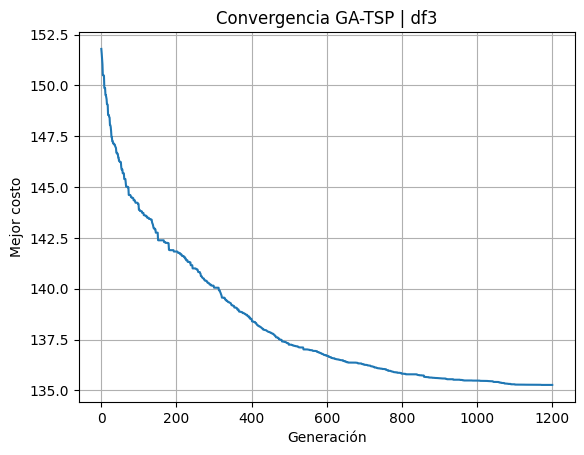

Mejor ruta (IDs): [313, 283, 68, 18, 98, 108, 106, 103, 364, 7, 112, 379, 11, 56, 143, 9, 134, 34, 131, 87, 196, 382, 336, 200, 265, 302, 339, 258, 249, 398, 153, 162, 412, 311, 353, 373, 260, 250, 363, 390, 223, 173, 384, 190, 270, 215, 159, 264, 237, 248, 259, 388, 312, 409, 175, 160, 351, 247, 261, 337, 170, 83, 335, 244, 191, 163, 304, 323, 318, 344, 182, 204, 165, 222, 380, 275, 426, 157, 286, 225, 203, 413, 158, 393, 219, 227, 345, 208, 332, 418, 230, 179, 226, 284, 366, 228, 271, 301, 281, 77, 385, 411, 177, 316, 420, 167, 74, 181, 148, 93, 10, 105, 341, 8, 92, 1, 99, 123, 62, 29, 90, 94, 15, 31, 127, 97, 4, 146, 84, 85, 20, 73, 71, 140, 135, 61, 3, 80, 115, 356, 198, 346, 357, 416, 290, 276, 150, 151, 168, 291, 187, 391, 299, 402, 119, 107, 67, 121, 64, 30, 137, 46, 120, 144, 52, 129, 109, 423, 320, 378, 331, 195, 428, 263, 267, 288, 343, 273, 383, 212, 349, 365, 232, 425, 256, 279, 240, 415, 400, 246, 252, 241, 427, 381, 174, 193, 376, 421, 272, 266]

=== Hoja 4 (df4) ===
Gen 

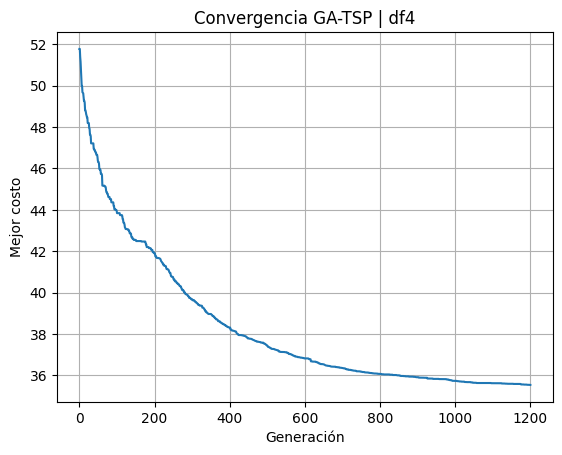

Mejor ruta (IDs): [239, 427, 353, 252, 386, 392, 334, 207, 233, 260, 296, 309, 362, 297, 372, 371, 232, 425, 288, 152, 413, 383, 352, 209, 358, 208, 367, 359, 253, 158, 275, 279, 415, 277, 396, 266, 390, 180, 283, 320, 189, 238, 329, 190, 410, 262, 68, 304, 244, 323, 204, 324, 335, 83, 195, 290, 149, 154, 337, 229, 294, 170, 251, 312, 248, 259, 269, 172, 387, 291, 289, 247, 351, 315, 160, 285, 409, 198, 216, 338, 356, 206, 377, 357, 346, 217, 375, 129, 50, 133, 45, 41, 107, 125, 64, 134, 16, 145, 51, 96, 100, 13, 110, 75, 11, 24, 143, 70, 1, 27, 201, 124, 167, 397, 420, 210, 171, 376, 242, 245, 316, 385, 176, 271, 230, 278, 424, 411, 8, 88, 281, 350, 37, 72, 98, 18, 255, 270, 395, 141, 34, 364, 7, 28, 112, 389, 118, 5, 26, 136, 21, 3, 80, 101, 114, 53, 85, 19, 95, 54, 122, 61, 6, 39, 142, 25, 128, 138, 40, 90, 23, 31, 81, 94, 111, 44, 60, 93, 148, 341, 78, 76, 92, 32, 370, 319, 368, 284, 185, 421, 236, 193, 412, 268, 340, 405, 265, 398, 293, 258]

=== Hoja 5 (df5) ===
Gen    1 | Best =

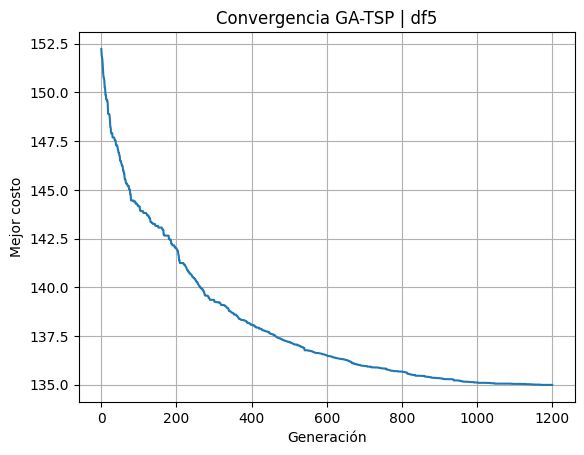

Mejor ruta (IDs): [159, 83, 195, 344, 182, 204, 288, 403, 267, 263, 428, 291, 187, 308, 327, 154, 197, 170, 276, 354, 206, 259, 338, 409, 285, 216, 198, 388, 312, 247, 351, 356, 375, 133, 144, 67, 120, 121, 63, 30, 38, 137, 46, 115, 84, 6, 147, 135, 114, 3, 101, 80, 69, 96, 51, 16, 145, 9, 42, 103, 399, 7, 28, 18, 82, 86, 43, 27, 47, 188, 210, 397, 420, 167, 177, 74, 307, 8, 91, 92, 76, 201, 123, 350, 280, 124, 88, 341, 0, 70, 56, 143, 20, 21, 13, 22, 100, 19, 128, 4, 146, 95, 35, 55, 127, 142, 31, 90, 79, 78, 282, 271, 317, 306, 230, 166, 192, 332, 284, 228, 179, 185, 174, 193, 272, 385, 242, 245, 236, 381, 386, 376, 311, 412, 241, 427, 334, 213, 194, 347, 400, 296, 396, 417, 305, 202, 275, 157, 372, 371, 232, 286, 365, 254, 253, 219, 231, 212, 349, 243, 225, 374, 309, 345, 367, 169, 415, 224, 339, 405, 302, 313, 283, 173, 423, 320, 331, 303, 190, 215, 330, 163, 221, 329, 131, 14, 72, 117, 304, 109, 402, 141, 36, 50, 255, 410, 217, 269, 346, 357]

=== Hoja 6 (df6) ===
Gen    1 | Best 

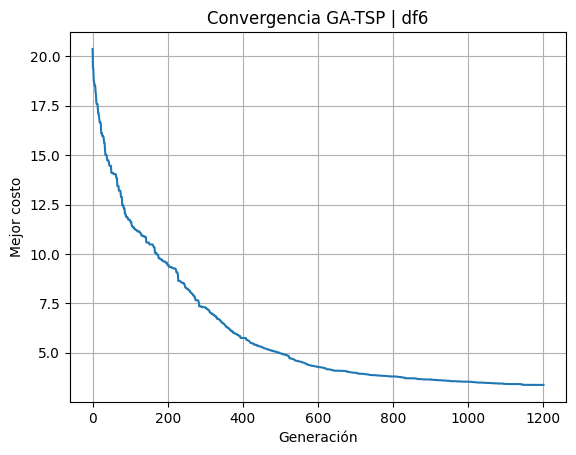

Mejor ruta (IDs): [225, 367, 348, 309, 222, 156, 347, 246, 213, 250, 400, 390, 323, 414, 163, 331, 238, 189, 330, 384, 304, 378, 200, 153, 249, 339, 405, 162, 293, 194, 252, 427, 311, 242, 257, 27, 57, 124, 420, 161, 321, 201, 78, 105, 79, 148, 59, 24, 49, 17, 110, 20, 61, 84, 6, 35, 97, 4, 138, 127, 111, 44, 60, 23, 90, 70, 29, 15, 40, 85, 53, 101, 80, 96, 140, 100, 145, 21, 143, 26, 125, 38, 63, 107, 144, 41, 120, 116, 45, 133, 285, 300, 198, 269, 248, 216, 259, 351, 160, 211, 261, 251, 354, 355, 395, 262, 14, 37, 131, 98, 50, 235, 206, 229, 295, 391, 294, 289, 187, 291, 150, 149, 308, 327, 170, 335, 274, 270, 255, 119, 141, 130, 7, 42, 118, 86, 82, 43, 5, 126, 104, 87, 47, 336, 188, 307, 317, 316, 171, 376, 193, 306, 230, 411, 422, 271, 228, 424, 366, 284, 353, 392, 334, 233, 260, 380, 256, 202, 277, 415, 165, 324, 344, 184, 204, 305, 428, 267, 403, 413, 349, 212, 209, 383, 273, 231, 359, 254, 298, 426, 374, 219, 227, 208, 169, 425, 342, 157, 232, 286]

=== Hoja 7 (df7) ===
Gen    1

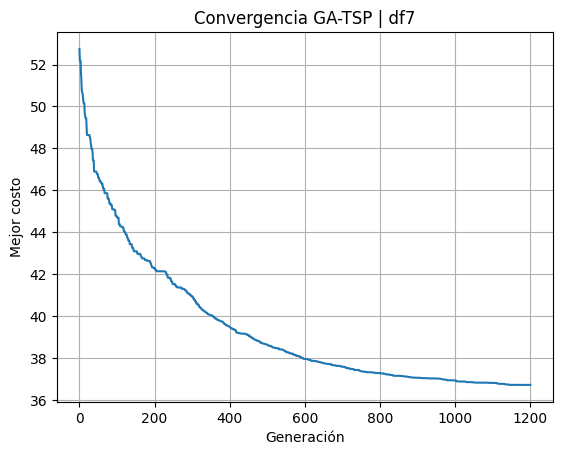

Mejor ruta (IDs): [385, 317, 411, 179, 166, 284, 185, 314, 213, 373, 296, 227, 218, 359, 254, 298, 394, 219, 231, 383, 413, 292, 365, 425, 256, 371, 372, 220, 275, 279, 202, 419, 360, 225, 203, 403, 263, 428, 288, 165, 415, 156, 233, 406, 183, 244, 221, 395, 410, 164, 384, 330, 262, 18, 125, 121, 137, 46, 64, 134, 73, 135, 147, 53, 4, 95, 15, 31, 142, 332, 192, 39, 69, 51, 71, 145, 26, 24, 56, 29, 132, 44, 10, 60, 105, 92, 32, 27, 123, 201, 48, 280, 181, 282, 176, 382, 328, 104, 14, 68, 423, 313, 189, 270, 299, 404, 159, 214, 391, 155, 401, 154, 327, 151, 290, 416, 170, 150, 294, 261, 172, 409, 259, 216, 248, 312, 211, 175, 285, 235, 361, 346, 237, 255, 52, 116, 120, 58, 141, 34, 103, 106, 118, 5, 43, 87, 162, 408, 339, 153, 199, 250, 277, 322, 204, 178, 323, 318, 195, 83, 335, 304, 173, 340, 265, 224, 266, 236, 193, 228, 366, 306, 370, 368, 47, 126, 59, 86, 379, 110, 21, 85, 12, 138, 54, 66, 23, 93, 62, 0, 57, 341, 33, 321, 422, 74, 307, 421, 77, 316]

=== Hoja 8 (df8) ===
Gen    1 | 

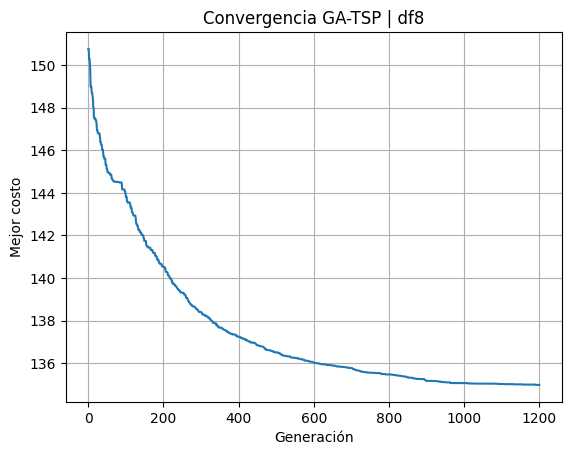

Mejor ruta (IDs): [420, 397, 280, 210, 336, 328, 242, 385, 177, 161, 317, 181, 230, 278, 424, 325, 368, 179, 176, 350, 382, 171, 174, 376, 311, 381, 287, 353, 239, 246, 347, 258, 390, 266, 277, 202, 157, 286, 362, 394, 243, 203, 383, 343, 152, 220, 169, 419, 158, 365, 425, 428, 407, 263, 267, 292, 297, 256, 298, 218, 345, 358, 207, 194, 252, 213, 241, 314, 293, 224, 398, 199, 87, 283, 313, 331, 320, 329, 117, 262, 18, 103, 364, 75, 9, 73, 134, 51, 96, 69, 22, 138, 55, 122, 4, 97, 54, 35, 135, 147, 140, 114, 115, 63, 125, 45, 235, 206, 388, 186, 312, 326, 211, 300, 285, 160, 269, 338, 216, 198, 356, 259, 346, 248, 172, 391, 295, 251, 261, 229, 337, 154, 290, 291, 168, 187, 308, 150, 264, 159, 83, 204, 182, 380, 156, 400, 415, 363, 250, 408, 183, 244, 190, 163, 330, 410, 255, 119, 141, 130, 28, 144, 52, 58, 36, 129, 395, 270, 217, 299, 221, 355, 191, 274, 304, 189, 402, 68, 131, 112, 43, 113, 59, 99, 126, 24, 56, 49, 132, 136, 40, 66, 25, 90, 139, 79, 0, 123, 301, 48]

=== Hoja 9 (df9) =

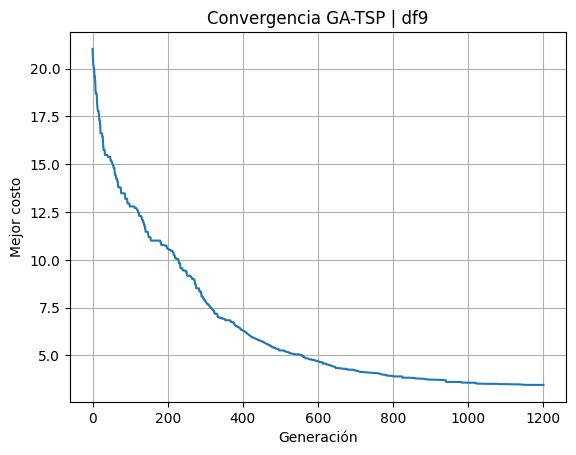

Mejor ruta (IDs): [403, 360, 232, 152, 203, 243, 349, 231, 393, 362, 169, 367, 309, 275, 240, 417, 396, 249, 293, 258, 153, 171, 272, 193, 174, 381, 347, 233, 239, 287, 284, 421, 87, 402, 355, 190, 163, 304, 244, 330, 378, 329, 180, 313, 331, 183, 344, 324, 323, 195, 83, 159, 214, 172, 175, 326, 211, 315, 216, 198, 409, 285, 356, 338, 259, 388, 312, 401, 197, 327, 168, 289, 150, 154, 187, 276, 290, 310, 155, 377, 357, 237, 375, 50, 116, 144, 67, 137, 38, 121, 28, 112, 7, 399, 86, 113, 196, 210, 280, 167, 74, 181, 422, 321, 8, 32, 92, 33, 192, 306, 278, 166, 366, 185, 228, 325, 316, 382, 281, 177, 420, 124, 57, 341, 79, 105, 99, 59, 27, 201, 148, 62, 10, 60, 15, 23, 142, 25, 66, 54, 146, 35, 53, 122, 95, 147, 114, 140, 55, 12, 138, 31, 90, 44, 29, 49, 56, 143, 100, 13, 96, 51, 364, 131, 14, 126, 17, 110, 11, 75, 73, 145, 16, 63, 120, 45, 235, 255, 221, 384, 302, 266, 400, 296, 277, 256, 365, 157, 225, 374, 158, 227, 345, 218, 348, 358, 208, 413, 263, 267]

=== Hoja 10 (df10) ===
Gen    

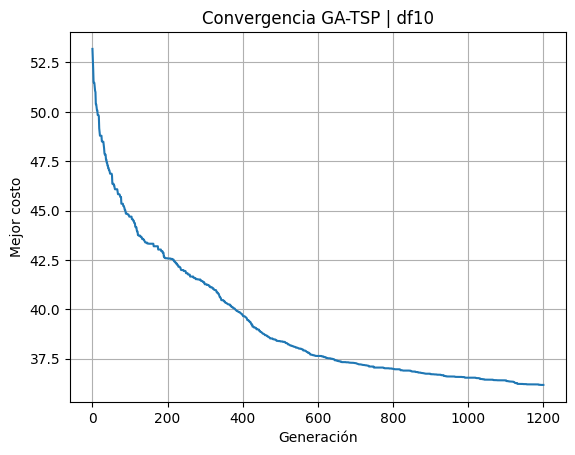

Mejor ruta (IDs): [350, 336, 210, 77, 385, 421, 397, 88, 47, 113, 86, 82, 104, 37, 131, 68, 117, 283, 378, 189, 238, 191, 215, 410, 355, 221, 335, 184, 344, 182, 240, 279, 256, 419, 380, 309, 425, 225, 157, 372, 297, 288, 267, 263, 273, 349, 383, 413, 243, 209, 212, 393, 219, 208, 205, 227, 359, 253, 394, 426, 360, 165, 204, 318, 195, 170, 187, 401, 229, 261, 369, 294, 289, 308, 151, 168, 149, 154, 310, 299, 274, 330, 384, 320, 313, 266, 250, 260, 233, 392, 287, 213, 398, 408, 268, 340, 328, 376, 370, 282, 74, 422, 181, 161, 27, 99, 87, 293, 252, 236, 366, 284, 185, 228, 319, 418, 230, 278, 8, 76, 2, 111, 12, 55, 23, 81, 66, 54, 39, 4, 146, 35, 135, 140, 13, 69, 16, 21, 26, 17, 75, 364, 130, 52, 235, 338, 312, 387, 326, 247, 175, 300, 285, 315, 259, 377, 375, 237, 270, 395, 119, 50, 141, 402, 98, 379, 108, 106, 42, 399, 112, 107, 45, 120, 137, 64, 71, 80, 3, 101, 6, 100, 22, 90, 10, 60, 93, 70, 136, 5, 123, 59, 57, 341, 139, 79, 92, 32, 272, 382]


,sheet,best_cost,n
0,df1,3.127602,200
1,df10,36.165490,200
2,df2,145.624517,200
3,df3,135.265436,200
4,df4,35.540773,200
5,df5,134.987337,200
6,df6,3.372109,200
7,df7,36.723457,200
8,df8,134.978263,200
9,df9,3.457707,200


,sheet,route_ids,length_nodes
0,df1,346->269->198->160->356->248->312->326->211->3...,200
1,df10,350->336->210->77->385->421->397->88->47->113-...,200
2,df2,213->392->194->252->386->207->233->296->260->4...,200
3,df3,313->283->68->18->98->108->106->103->364->7->1...,200
4,df4,239->427->353->252->386->392->334->207->233->2...,200
5,df5,159->83->195->344->182->204->288->403->267->26...,200
6,df6,225->367->348->309->222->156->347->246->213->2...,200
7,df7,385->317->411->179->166->284->185->314->213->3...,200
8,df8,420->397->280->210->336->328->242->385->177->1...,200
9,df9,403->360->232->152->203->243->349->231->393->3...,200


Guardados: tsp_ga_results_summary.csv, tsp_ga_best_routes_ids.csv


In [ ]:
GA_PARAMS = dict(
    pop_size=220,
    generations=1200,
    elite_size=2,
    tournament_k=3,
    mutation_prob=0.25,
    crossover_perc=1.0,
    patience=250,
    seed=123,
    verbose=True
)

all_results = []
routes_rows = []

for i, df in enumerate(dfs, start=1):
    print(f"\n=== Hoja {i} (df{i}) ===")
    dist, labels = to_distance_matrix_with_labels(df)
    route, cost, hist = ga_tsp(dist, **GA_PARAMS)
    all_results.append({"sheet": f"df{i}", "best_cost": cost, "n": dist.shape[0]})
    routes_rows.append({
        "sheet": f"df{i}",
        "route_ids": "->".join(map(str, route_to_labels(route, labels))),
        "length_nodes": len(route)
    })
    plot_history(hist, title=f"Convergencia GA-TSP | df{i}")
    print("Mejor ruta (IDs):", route_to_labels(route, labels))

res_df = pd.DataFrame(all_results).sort_values("sheet").reset_index(drop=True)
routes_df = pd.DataFrame(routes_rows).sort_values("sheet").reset_index(drop=True)

display(res_df)
display(routes_df)

res_df.to_csv("tsp_ga_results_summary.csv", index=False)
routes_df.to_csv("tsp_ga_best_routes_ids.csv", index=False)
print("Guardados: tsp_ga_results_summary.csv, tsp_ga_best_routes_ids.csv")

Promedios (s): {40: 6.572, 100: 48.723, 150: 100.08, 200: 166.79999999999998}


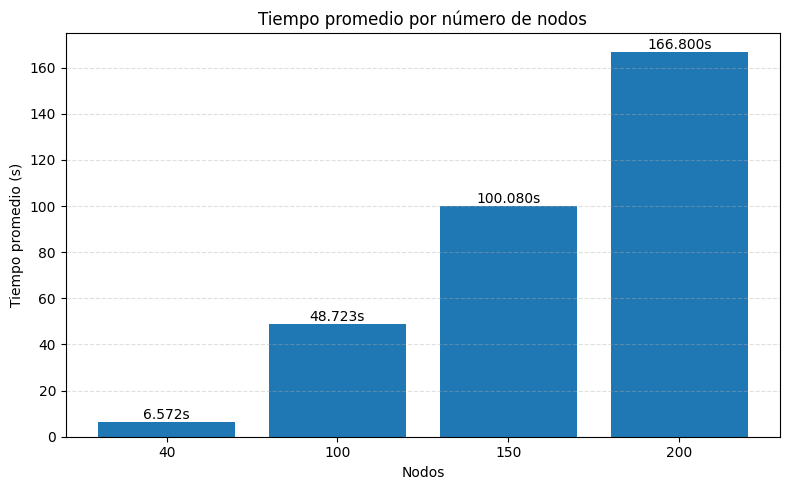

Figura guardada como: promedio_tiempo_por_nodos.png


In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# Tiempos (s) compartidos por instancia
t40  = [5.77, 7.78, 5.05, 7.09, 6.28, 5.28, 6.83, 4.63, 11.19, 5.82]
t100 = [40.88, 49.26, 50.87, 50.80, 50.85, 50.89, 50.76, 40.94, 51.25, 50.73]
t150 = [100.32, 99.93, 99.82, 99.94, 100.32, 100.16, 100.07, 100.29, 100.01, 99.94]
t200 = [167.80, 166.26, 166.65, 167.39, 166.21, 166.57, 167.26, 166.03, 167.31, 166.52]

means = [
    float(np.mean(t40)),
    float(np.mean(t100)),
    float(np.mean(t150)),
    float(np.mean(t200)),
]
nodes = [40, 100, 150, 200]

print("Promedios (s):", dict(zip(nodes, means)))

# === Gráfica de barras ===
plt.figure(figsize=(8,5))
bars = plt.bar([str(n) for n in nodes], means)

# Etiquetas numéricas encima de cada barra
for b, m in zip(bars, means):
    plt.text(b.get_x() + b.get_width()/2, b.get_height(),
             f"{m:.3f}s", ha='center', va='bottom', fontsize=10)

plt.title("Tiempo promedio por número de nodos")
plt.xlabel("Nodos")
plt.ylabel("Tiempo promedio (s)")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("promedio_tiempo_por_nodos.png", dpi=150)
plt.show()

print("Figura guardada como: promedio_tiempo_por_nodos.png")


Promedios (s): {np.int64(40): np.float64(6.572), np.int64(100): np.float64(48.723), np.int64(150): np.float64(100.08), np.int64(200): np.float64(166.79999999999998)}
R² lineal     : 0.9791  (y = -41.6581 + 0.997566·n)
R² exponencial: 0.7182  (y ≈ exp(1.4321 + 0.019925·n))


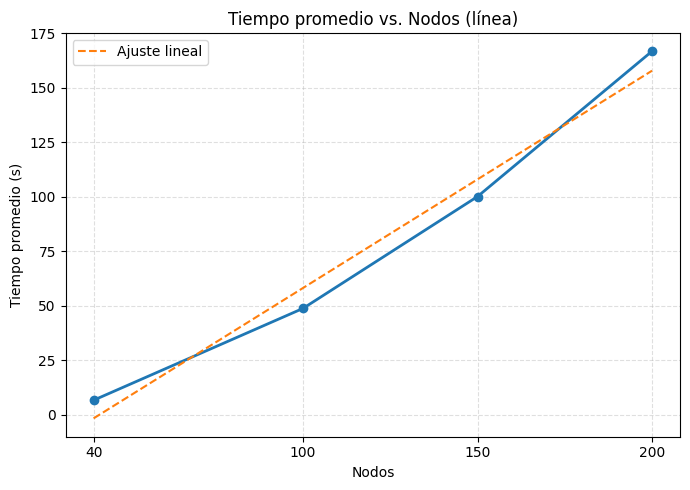

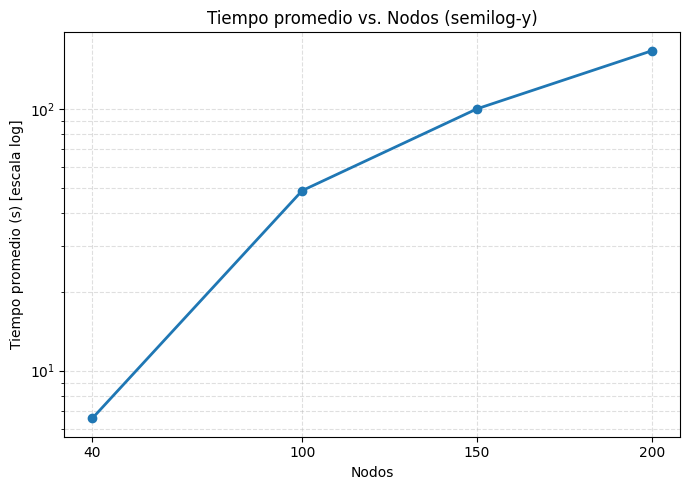

Segundas diferencias aproximadas (indicador de curvatura):
[ 9.206 15.363]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Datos (tiempos por corrida)
t40  = [5.77, 7.78, 5.05, 7.09, 6.28, 5.28, 6.83, 4.63, 11.19, 5.82]
t100 = [40.88, 49.26, 50.87, 50.80, 50.85, 50.89, 50.76, 40.94, 51.25, 50.73]
t150 = [100.32, 99.93, 99.82, 99.94, 100.32, 100.16, 100.07, 100.29, 100.01, 99.94]
t200 = [167.80, 166.26, 166.65, 167.39, 166.21, 166.57, 167.26, 166.03, 167.31, 166.52]

nodes = np.array([40, 100, 150, 200], dtype=float)
means = np.array([
    np.mean(t40),
    np.mean(t100),
    np.mean(t150),
    np.mean(t200),
], dtype=float)

print("Promedios (s):", dict(zip(nodes.astype(int), means)))

# --------- Ajustes y R^2 ----------
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

# Lineal: y = a + b x
A_lin = np.vstack([np.ones_like(nodes), nodes]).T
coef_lin, *_ = np.linalg.lstsq(A_lin, means, rcond=None)
a_lin, b_lin = coef_lin
pred_lin = a_lin + b_lin * nodes
r2_lin = r2_score(means, pred_lin)

# Exponencial: y = c * exp(k x)  ->  ln y = ln c + k x

if np.all(means > 0):
    logy = np.log(means)
    A_exp = np.vstack([np.ones_like(nodes), nodes]).T
    coef_exp, *_ = np.linalg.lstsq(A_exp, logy, rcond=None)
    ln_c, k = coef_exp
    pred_exp = np.exp(ln_c + k * nodes)
    r2_exp = r2_score(means, pred_exp)
else:
    pred_exp = np.full_like(means, np.nan)
    r2_exp = np.nan

print(f"R² lineal     : {r2_lin:.4f}  (y = {a_lin:.4f} + {b_lin:.6f}·n)")
if np.isfinite(r2_exp):
    print(f"R² exponencial: {r2_exp:.4f}  (y ≈ exp({ln_c:.4f} + {k:.6f}·n))")

# --------- Gráfica de línea (valor real + ajuste lineal) ----------
plt.figure(figsize=(7,5))
plt.plot(nodes, means, marker='o', linewidth=2)
plt.plot(nodes, pred_lin, linestyle='--', label='Ajuste lineal')
plt.xticks(nodes, nodes.astype(int))
plt.xlabel("Nodos")
plt.ylabel("Tiempo promedio (s)")
plt.title("Tiempo promedio vs. Nodos (línea)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

# --------- Vista semilog (y-log). Una recta aquí sugiere exponencial ----------
plt.figure(figsize=(7,5))
plt.semilogy(nodes, means, marker='o', linewidth=2)
plt.xticks(nodes, nodes.astype(int))
plt.xlabel("Nodos")
plt.ylabel("Tiempo promedio (s) [escala log]")
plt.title("Tiempo promedio vs. Nodos (semilog-y)")
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


if len(nodes) >= 3:
    # segunda diferencia sobre los medios (equiespaciado en x no perfecto, pero orientativo)
    # Usamos una interpolación simple a pasos medios por claridad
    print("Segundas diferencias aproximadas (indicador de curvatura):")
    # Reescalar x a índice 0..m-1 para una métrica simple
    y = means
    d2 = y[:-2] - 2*y[1:-1] + y[2:]
    print(d2)
